<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">

<br>

<h1 style="font-family:verdana; font-size:26px"><center>~ BirdCLEF 2026: Proper EDA + Insights ~</center></h1>
<h3 style="font-family:verdana; font-size:14px; color:gray"><center>Wildlife species identification from Pantanal soundscapes</center></h3>

<br>

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">


***Made with love by:*** *zirach*

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">

<br>

# Table of Contents

1. [**Introduction**](#1)

2. [**Initialization**](#2)

3. [**Data Audit**](#3)

4. [**Explanatory Data Analysis**](#4)


<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">

# Introduction <a name="1"></a>

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">


## Motivation

This notebook was written to turn the BirdCLEF 2026 data into a usable modeling map before any training choices were locked in. The goal is to summarize the dataset in a way that informs modeling decisions, which labels look reliable, how far the training geography drifts from the Pantanal target, how birds and frogs differ in timing and overlap, and which quirks should shape validation, augmentation, and post-processing.

That matters here because the competition data is not a single clean pool. It mixes <code>train_audio</code>, partially labeled soundscapes, strong class imbalance, secondary labels, and a target environment that is represented only indirectly by much of the training corpus. A careful EDA notebook therefore becomes part of the modeling pipeline itself.

It helps decide what should be trusted, what should be downweighted, and which priors are worth encoding before moving on to embeddings, probes, or full training.


---

## Reference Shoutouts

- [`train_soundscapes_labels.csv` has duplicated records](https://www.kaggle.com/competitions/birdclef-2026/discussion/681297) by ttahara (Tawara)
- [BirdCLEF 2026 Comprehensive EDA](https://www.kaggle.com/code/jiweiliu/birdclef-2026-comprehensive-eda) by jiweiliu (Jiwei Liu)
- [BirdCLEF Strategic EDA + Augmentation Guide JP/EN](https://www.kaggle.com/code/kebaka/birdclef-strategic-eda-augmentation-guid-jp-en) by kebaka (kaguo)
- [BirdCLEF2026 Analysis Report](https://www.kaggle.com/competitions/birdclef-2026/discussion/681146) by tom99763 (Tom)

---

## BirdCLEF+ 2026

Identifying wildlife species from passive acoustic recordings in Brazil's Pantanal wetlands.

- **Task**: multi-label classification over 234 species in 5-second soundscape windows
- **Metric**: macro-averaged ROC-AUC, species with no test positives are excluded from scoring
- **Constraint**: CPU-only notebook, 90-minute runtime, no internet at inference

---

## Dataset

*The data for this experiment comes from the BirdCLEF+ 2026 competition on Kaggle: https://www.kaggle.com/competitions/birdclef-2026/data*

*This dataset contains audio recordings from passive acoustic monitoring in the biodiverse Pantanal wetlands of South America. It includes bird, amphibian, mammal, reptile, and insect vocalizations, with labeled training data, unlabeled soundscapes, and test clips.*

*The recordings capture complex soundscapes with overlapping calls across different habitats and seasons. The main challenges are the large volume of audio, limited labels for rare species, and multi-species interference.*

*The goal is to build machine learning models that automatically identify vocalizing wildlife species in audio clips to support biodiversity monitoring and conservation in visually challenging environments.*

### Directory

**train_audio/**

The training data consists of short recordings of individual bird, amphibian, reptile, mammal, and insect sounds generously uploaded by users of `xeno-canto.org` and `iNaturalist`. These files have been resampled to 32 kHz where applicable to match the test set audio and converted to the ogg format. Filenames consist of `[collection][file_id_in_collection].ogg`. The training data should have nearly all relevant files

Host expects there is no benefit to looking for more on `xeno-canto.org` or `iNaturalist` and appreciate your cooperation in limiting the burden on their servers.

**test_soundscapes/**

When submitting a notebook, the `test_soundscapes` directory will be populated with approximately 600 recordings to be used for scoring. 

They are 1 minute long and in ogg audio format, resampled to 32 kHz. The file names have the general form of `BC2026_Test_<file ID>_<site>_<date>_<time in UTC>.ogg` (e.g., file `BC2026_Test_0001_S05_20250227_010002.ogg` has file ID 0001, was recorded at site S05 on Feb 27 2025 at 01:00 UTC).

It should take your submission notebook approximately five minutes to load all the test soundscapes. Not all species from the training data actually occur in the test data.

**train_soundscapes/** 

Additional audio data from roughly the same recording locations as the test_soundscapes. Filenames follow the same naming convention as the test_soundscapes.

Although some recording sites overlap between train and test, precise recording dates and times do NOT overlap with recordings of the hidden test data. This year, some of the `train_soundscapes` have been labeled by expert annotators.

### Metadata

**taxonomy.csv**

Data on the different species, including iNaturalist taxon ID and class name (Aves, Amphibia, Mammalia, Insecta, Reptilia). Most insect species in this competition have not been **identified on species level and instead occur as sonotypes** (e.g., `47158son16` as insect sonotype 16)

1.  `primary_label`          : bla bla bla

2.  `inat_taxon_id`          : bla bla bla

3.  `scientific_name`        : bla bla bla

4.  `common_name`            : bla bla bla

5.  `class_name`             : bla bla bla

These sonotypes are treated as classes despite the lack of species ID and some of them also occur in the test data. The 234 rows of this file represent the 234 class columns in the submission file. `primary_label` specifies the submission file column name.

**train.csv**

A wide range of metadata is provided for the training data. The most directly relevant fields are:

1.  `primary_label`: A code for the species (eBird code for birds, iNaturalist taxon ID for non-birds). You can review detailed information about the species by appending codes to eBird and iNaturalist taxon URL, such as `https://ebird.org/species/brnowl` for the Barn Owl or `https://www.inaturalist.org/taxa/41970` for the Jaguar. Not all species have their own pages; some links might fail.

2.  `secondary_labels`: List of species labels that have been marked by recordists to also occur in the recording. Can be incomplete.

3.  `latitude` & `longitude`: Coordinates for where the recording was taken. Some bird species may have local call 'dialects,' so you may want to seek geographic diversity in your training data.
 
4.  `author`: The user who provided the recording.

5.  `Unknown` if no name was provided.

6.  `filename`: The name of the associated audio file.

7.  `rating`: Values in 1..5 (1 - low quality, 5 - high quality; 0.5 reduction in rating when background species are present) provided by users of Xeno-canto; 0 implies no rating is available; iNaturalist does not provide quality ratings.

8.  `collection`: Either XC or iNat, indicating which collection the recording was taken from. Filenames also reference the collection and the ID within that collection.

**train_soundscapes_labels.csv**

This year, some of the `train_soundscapes` have been labeled by expert annotators, and we provide the ground truth for a subset of `train_soundscapes` in `train_soundscapes_labels.csv`

1.  `filename`          : the soundscape file

2.  `start` & `end`     : the 5-second segment for which column in label
 
3.  `primary_label`     : a semicolon-separated list of species codes that have been marked as present in this segment.

**recording_location.txt**

Some high-level information on the recording location (Pantanal, Brazil).

### Submission

A valid sample submission.

1.  `row_id`        : A slug of `[soundscape_filename]_[end_time]` for the prediction; e.g., Segment 00:15-00:20 of 1-minute test soundscape `BC2026_Test_0001_S05_20250227_010002.ogg` has row ID `BC2026_Test_0001_S05_20250227_010002_20`.

2.  `[species_id]`  : There are 234 species ID columns, need to predict the probability of the presence of each species for each row.

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">

# Initialization <a name="2"></a>

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">


## Environment

In [1]:
import os, platform, sys
print('Python :', sys.version)
print('OS     :', platform.system(), platform.release())
print('CWD    :', os.getcwd())

Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS     : Linux 6.6.113+
CWD    : /kaggle/working


---

## Libraries

In [2]:
import random
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import ast

from itertools import combinations
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [3]:
print('NumPy      :', np.__version__)
print('Pandas     :', pd.__version__)

NumPy      : 2.0.2
Pandas     : 2.3.3


---

## Settings

> `Settings` holds all hyperparameters and paths in one place.

> **Cache auto-detection**: if pre-computed Perch arrays are found in any of the candidate directories, `CACHE_EXISTS = True` and the inference cell skips generation automatically. To force a re-run, delete or move the cached files.

In [4]:
class Settings:
    # Mode ------------------------------------------------------------------
    SEED = 42

    # Competition paths -----------------------------------------------------
    _KAGGLE_BASE = Path('/kaggle/input/competitions/birdclef-2026')
    _LOCAL_BASE  = Path('../dataset')
    BASE = _KAGGLE_BASE if _KAGGLE_BASE.exists() else _LOCAL_BASE

    # EDA output ------------------------------------------------------------
    OUT_DIR = Path('../outputs/eda')
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # Cache -----------------------------------------------------------------
    DUR_CACHE = OUT_DIR / 'duration_clip_cache.csv'

CFG = Settings()

In [5]:
print(f'BASE : {CFG.BASE}')

BASE : /kaggle/input/competitions/birdclef-2026


---

## Seed

In [6]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

In [7]:
seed_everything(CFG.SEED)

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">

# Data Audit <a name="3"></a>

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">


## Metadata

In [8]:
taxonomy        = pd.read_csv(CFG.BASE / 'taxonomy.csv')
train_meta      = pd.read_csv(CFG.BASE / 'train.csv')
soundscape_lbls = pd.read_csv(CFG.BASE / 'train_soundscapes_labels.csv')
sample_sub      = pd.read_csv(CFG.BASE / 'sample_submission.csv')

---

## Shapes

In [9]:
taxonomy

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia
...,...,...,...,...,...
229,yebela1,16714,Elaenia flavogaster,Yellow-bellied Elaenia,Aves
230,yecmac,73272,Primolius auricollis,Golden-collared Macaw,Aves
231,yecpar,19215,Brotogeris chiriri,Yellow-chevroned Parakeet,Aves
232,yehcar1,1432779,Daptrius chimachima,Yellow-headed Caracara,Aves


In [10]:
train_meta

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35544,yeofly1,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,yeofly1/XC762473.ogg,XC
35545,yeofly1,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,yeofly1/XC818328.ogg,XC
35546,yeofly1,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,yeofly1/XC425545.ogg,XC
35547,yeofly1,[],['song'],3.3821,-61.4464,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/456230/download,yeofly1/XC456230.ogg,XC


In [11]:
soundscape_lbls

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380
...,...,...,...,...
1473,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380
1474,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146
1475,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146
1476,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,517063;555146;66971


In [12]:
sample_sub

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


---

## Duplicates

In [13]:
taxonomy[taxonomy.duplicated(keep=False)]

,primary_label,inat_taxon_id,scientific_name,common_name,class_name


In [14]:
train_meta[train_meta.duplicated(keep=False)]

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection


In [15]:
soundscape_lbls[soundscape_lbls.duplicated(keep=False)]

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380
...,...,...,...,...
1473,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380
1474,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146
1475,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146
1476,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,517063;555146;66971


In [16]:
sample_sub[sample_sub.duplicated(keep=False)]

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The raw <code>soundscape_lbls</code> file contains <strong>1,478 rows</strong>, but <strong>739</strong> of them are exact duplicates. The duplicate table above shows the issue directly, and the notebook drops those repeated rows before the later soundscape analysis begins.</p>

</div>

In [17]:
soundscape_lbls.drop_duplicates(keep='first', inplace=True)

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">

# Explanatory Data Analysis <a name="4"></a>

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">


In [18]:
PRIMARY_LABELS = sample_sub.columns[1:].tolist()
N_CLASSES      = len(PRIMARY_LABELS)
label_to_idx   = {c: i for i, c in enumerate(PRIMARY_LABELS)}

---

## Train Meta

### Class Distribution

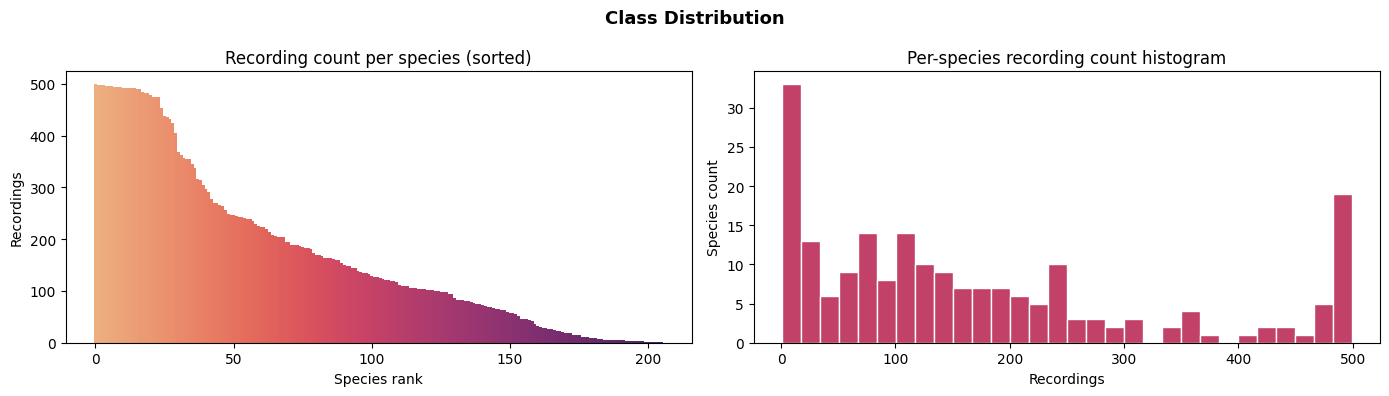

Species with recordings : 206 / 234
Species with < 10 clips : 25
Species with < 50 clips : 52
Max : 499 (rubthr1)
Min : 1


In [19]:
PALETTE = sns.color_palette('flare', 6)

counts = train_meta.groupby('primary_label').size().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

colors = sns.color_palette('flare', len(counts))
ax1.bar(range(len(counts)), counts.values, color=colors, width=1.0)
ax1.set_xlabel('Species rank'); ax1.set_ylabel('Recordings')
ax1.set_title('Recording count per species (sorted)')

ax2.hist(counts.values, bins=30, color=sns.color_palette('flare', 1)[0], edgecolor='white')
ax2.set_xlabel('Recordings'); ax2.set_ylabel('Species count')
ax2.set_title('Per-species recording count histogram')

fig.suptitle('Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Species with recordings : {len(counts)} / {N_CLASSES}')
print(f'Species with < 10 clips : {(counts < 10).sum()}')
print(f'Species with < 50 clips : {(counts < 50).sum()}')
print(f'Max : {counts.max()} ({counts.idxmax()})')
print(f'Min : {counts.min()}')

<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The training set contains <strong>35,549 recordings</strong> across <strong>206 of the 234</strong> submission classes. The class profile is not only a long tail. It also has a small high-count head near <strong>450 to 500 recordings</strong>, a broad middle shelf, and then a steep decline into the rare-species tail. Within that tail, <strong>25 species</strong> have fewer than <strong>10</strong> recordings and <strong>52</strong> have fewer than <strong>50</strong>, while <code>rubthr1</code> reaches <strong>499</strong>.</p>

<p style="color: #333;">That shape matters for training. A few dominant species can set the baseline too easily, many species sit in a medium-support regime, and a non-trivial minority remains severely data-poor. The histogram therefore supports <strong>weighted sampling</strong> or a loss that reduces domination by the frequent head classes.</p>

</div>

### Rating and Source

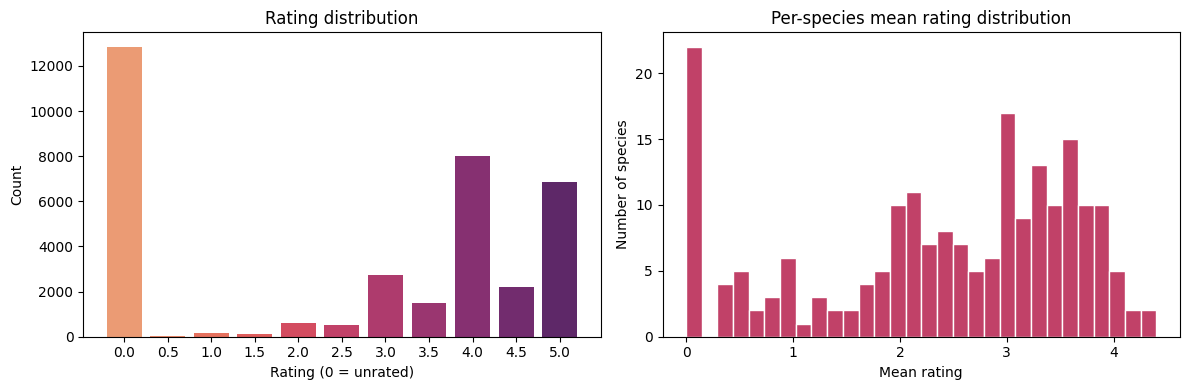

XC   : 23,043 recordings  mean rating 4.01
iNat : 12,506 recordings  mean rating 0.00


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_counts = train_meta['rating'].value_counts().sort_index()
pal = sns.color_palette('flare', len(rating_counts))
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color=pal)
axes[0].set_xlabel('Rating (0 = unrated)'); axes[0].set_ylabel('Count')
axes[0].set_title('Rating distribution')

mean_rating = train_meta.groupby('primary_label')['rating'].mean()
axes[1].hist(mean_rating.values, bins=30, color=sns.color_palette('flare', 1)[0], edgecolor='white')
axes[1].set_xlabel('Mean rating'); axes[1].set_ylabel('Number of species')
axes[1].set_title('Per-species mean rating distribution')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '02_rating_source.png', dpi=120, bbox_inches='tight')
plt.show()

xc   = train_meta[train_meta['collection'] == 'XC']
inat = train_meta[train_meta['collection'] == 'iNat']
print(f'XC   : {len(xc):,} recordings  mean rating {xc["rating"].mean():.2f}')
print(f'iNat : {len(inat):,} recordings  mean rating {inat["rating"].mean():.2f}')

<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">Ratings remain <strong>strongly bimodal</strong> at the clip level. Exactly <strong>12,849 recordings</strong> sit at <strong>0.0</strong>, driven mostly by iNaturalist. The largest rated bins sit at <strong>4.0 with 8,018 clips</strong> and <strong>5.0 with 6,845</strong>. XC contributes <strong>23,043 recordings</strong> with mean rating <strong>4.01</strong>, whereas all <strong>12,506 iNat recordings</strong> sit at <strong>0.0</strong> and an additional <strong>343 XC clips</strong> also sit at <strong>0.0</strong>.</p>

<p style="color: #333;">The per-species view is narrower than the raw clip histogram. Many species cluster around mean ratings of roughly <strong>3 to 4</strong>, while a separate zero-rated block remains. <strong>Rating-based filtering</strong> therefore only makes sense on the XC subset, and even there it should not assume every <strong>0.0</strong> clip is from iNat.</p>

</div>

### Geographic Distribution

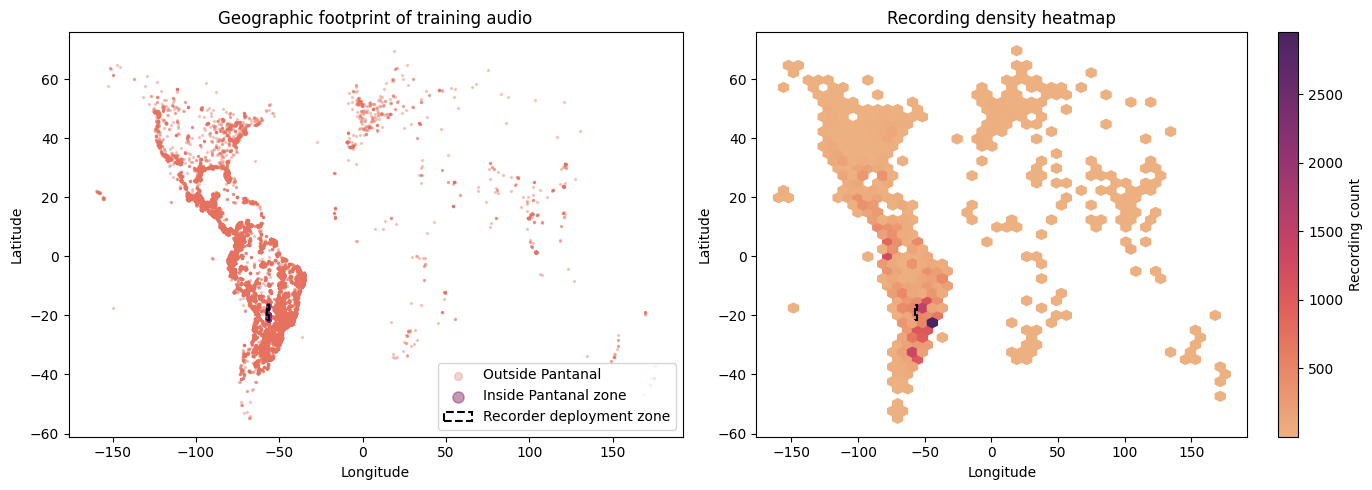

In Pantanal   : 847 (2.4%)
Out of region : 34,702 (97.6%)
Latitude range : -54.86 to 69.58
Longitude range: -159.66 to 175.32


In [21]:
PANTANAL = dict(lat_min=-21.6, lat_max=-16.5, lon_min=-57.6, lon_max=-55.9)

geo = train_meta.dropna(subset=['latitude', 'longitude']).copy()
in_region = (
    geo['latitude'].between(PANTANAL['lat_min'], PANTANAL['lat_max']) &
    geo['longitude'].between(PANTANAL['lon_min'], PANTANAL['lon_max'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(geo.loc[~in_region, 'longitude'], geo.loc[~in_region, 'latitude'],
                s=2, alpha=0.3, label='Outside Pantanal',
                color=sns.color_palette('flare', 3)[0])
axes[0].scatter(geo.loc[in_region, 'longitude'], geo.loc[in_region, 'latitude'],
                s=4, alpha=0.5, label='Inside Pantanal zone',
                color=sns.color_palette('flare', 3)[2])
axes[0].add_patch(Rectangle(
    (PANTANAL['lon_min'], PANTANAL['lat_min']),
    PANTANAL['lon_max'] - PANTANAL['lon_min'],
    PANTANAL['lat_max'] - PANTANAL['lat_min'],
    linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--',
    label='Recorder deployment zone'
))
axes[0].legend(markerscale=4)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Geographic footprint of training audio')

hex_plot = axes[1].hexbin(
    geo['longitude'],
    geo['latitude'],
    gridsize=45,
    cmap='flare',
    mincnt=1,
)
axes[1].add_patch(Rectangle(
    (PANTANAL['lon_min'], PANTANAL['lat_min']),
    PANTANAL['lon_max'] - PANTANAL['lon_min'],
    PANTANAL['lat_max'] - PANTANAL['lat_min'],
    linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--'
))
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Recording density heatmap')
fig.colorbar(hex_plot, ax=axes[1], label='Recording count')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '03_geographic.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'In Pantanal   : {in_region.sum():,} ({in_region.mean()*100:.1f}%)')
print(f'Out of region : {(~in_region).sum():,} ({(~in_region).mean()*100:.1f}%)')
print(f'Latitude range : {geo["latitude"].min():.2f} to {geo["latitude"].max():.2f}')
print(f'Longitude range: {geo["longitude"].min():.2f} to {geo["longitude"].max():.2f}')

<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">Only <strong>847 recordings</strong>, or <strong>2.4%</strong>, fall inside the Pantanal bounding box, while <strong>34,702</strong> sit outside it. The scatter plot shows the training audio is <strong>globally distributed</strong>, and the density heatmap makes the imbalance clearer, with recording activity clustered in a few external hotspots while the Pantanal remains a <strong>thinly sampled target region</strong>. That means the <strong>739 unique soundscape label segments</strong> carry disproportionate value, because they come from the deployment soundscape rather than the broader long-tail geography of <code>train_audio</code>.</p>

</div>


### Pantanal Zoom

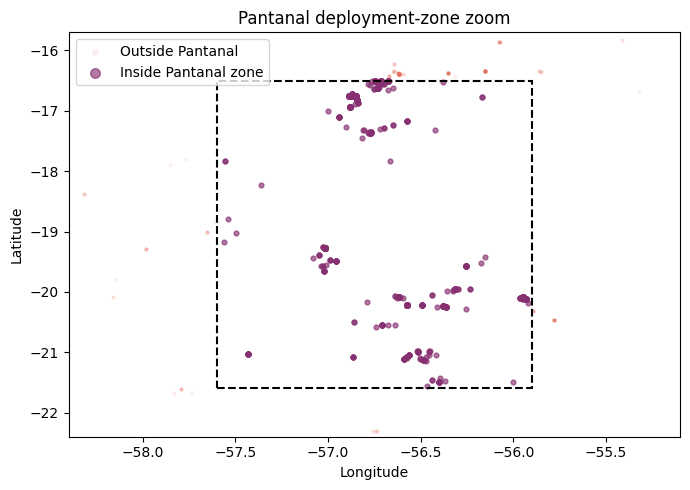

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(geo.loc[~in_region, 'longitude'], geo.loc[~in_region, 'latitude'],
           s=4, alpha=0.08, color=sns.color_palette('flare', 3)[0], label='Outside Pantanal')
ax.scatter(geo.loc[in_region, 'longitude'], geo.loc[in_region, 'latitude'],
           s=12, alpha=0.65, color=sns.color_palette('flare', 3)[2], label='Inside Pantanal zone')

pad_lon, pad_lat = 0.8, 0.8
ax.set_xlim(PANTANAL['lon_min'] - pad_lon, PANTANAL['lon_max'] + pad_lon)
ax.set_ylim(PANTANAL['lat_min'] - pad_lat, PANTANAL['lat_max'] + pad_lat)
ax.add_patch(Rectangle(
    (PANTANAL['lon_min'], PANTANAL['lat_min']),
    PANTANAL['lon_max'] - PANTANAL['lon_min'],
    PANTANAL['lat_max'] - PANTANAL['lat_min'],
    linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--'
))
ax.set_title('Pantanal deployment-zone zoom')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=2)
plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '03b_geographic_pantanal_zoom.png', dpi=120, bbox_inches='tight')
plt.show()

In [23]:
pantanal_geo = geo.loc[in_region].copy()
pantanal_counts = pantanal_geo['primary_label'].value_counts()

pantanal_summary = pd.Series({
    'Inside Pantanal recordings': len(pantanal_geo),
    'Inside Pantanal species': pantanal_geo['primary_label'].nunique(),
    'Species with >= 5 recordings': int((pantanal_counts >= 5).sum()),
    'Species with >= 10 recordings': int((pantanal_counts >= 10).sum()),
    'Species unique to Pantanal subset': len(set(pantanal_geo['primary_label']) - set(geo.loc[~in_region, 'primary_label'])),
}, name='value').to_frame()

pantanal_collection = (
    pantanal_geo['collection']
    .value_counts()
    .rename_axis('collection')
    .reset_index(name='recordings')
)

print('Pantanal subset summary')
display(pantanal_summary)
print('Collection split inside Pantanal')
display(pantanal_collection)


Pantanal subset summary


,value
Inside Pantanal recordings,847
Inside Pantanal species,119
Species with >= 5 recordings,53
Species with >= 10 recordings,31
Species unique to Pantanal subset,0


Collection split inside Pantanal


,collection,recordings
0,XC,740
1,iNat,107


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The zoomed view shows that the Pantanal subset is <strong>relevant</strong>, but still <strong>limited</strong>. The box contains <strong>847 recordings</strong> spanning <strong>119 species</strong>, so the local slice is not trivial in label breadth. Even so, only <strong>53 species</strong> have at least <strong>five</strong> recordings inside the box and only <strong>31</strong> reach <strong>ten or more</strong>, which means the local evidence becomes thin quickly once the analysis moves beyond the most common classes.</p>

<p style="color: #333;">The subset is also an <strong>adaptation problem</strong> rather than a discovery problem. Most Pantanal clips still come from <strong>XC, 740 versus 107 from iNat</strong>, and there are <strong>no species unique</strong> to the Pantanal box within <code>train_audio</code>. In practice, that makes the zoom useful less for adding new labels and more for identifying which existing species have enough geographically relevant support to justify <strong>location-aware priors</strong> or targeted validation.</p>

</div>

### Geographic Proximity to Pantanal


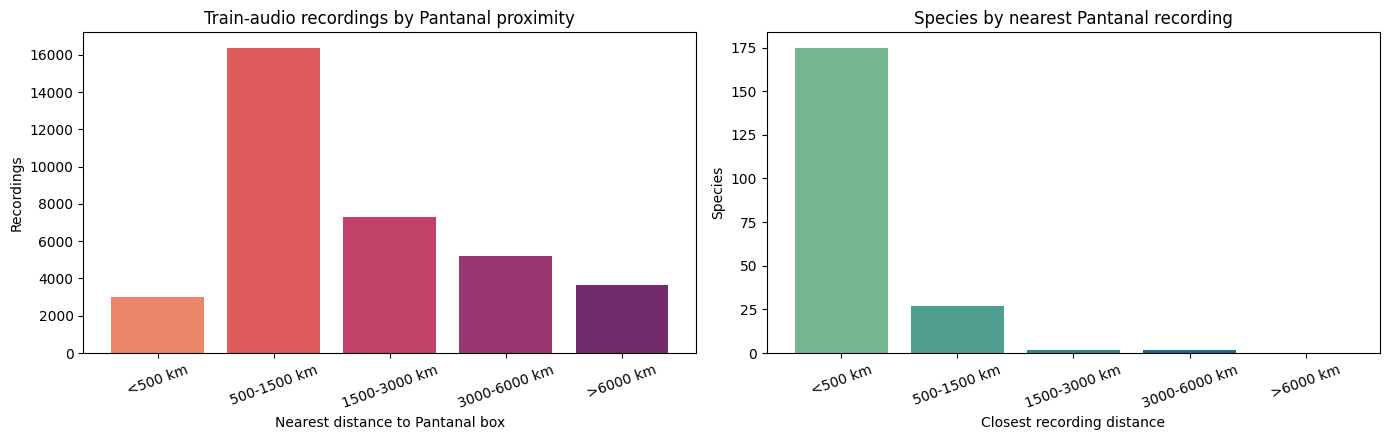

In [24]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

train_geo = train_meta.dropna(subset=['latitude', 'longitude']).copy()
train_geo['pantanal_lat'] = train_geo['latitude'].clip(PANTANAL['lat_min'], PANTANAL['lat_max'])
train_geo['pantanal_lon'] = train_geo['longitude'].clip(PANTANAL['lon_min'], PANTANAL['lon_max'])
train_geo['pantanal_distance_km'] = haversine_km(
    train_geo['latitude'].to_numpy(),
    train_geo['longitude'].to_numpy(),
    train_geo['pantanal_lat'].to_numpy(),
    train_geo['pantanal_lon'].to_numpy(),
)

DIST_BINS = [0, 500, 1500, 3000, 6000, np.inf]
DIST_LABELS = ['<500 km', '500-1500 km', '1500-3000 km', '3000-6000 km', '>6000 km']

train_geo['pantanal_bucket'] = pd.cut(
    train_geo['pantanal_distance_km'],
    bins=DIST_BINS,
    labels=DIST_LABELS,
    include_lowest=True,
    right=False,
)
recording_bucket_counts = train_geo['pantanal_bucket'].value_counts().reindex(DIST_LABELS, fill_value=0)

species_distance = (
    train_geo.groupby(['primary_label', 'common_name', 'class_name'], dropna=False)['pantanal_distance_km']
    .min()
    .reset_index()
)
species_distance['display_name'] = species_distance['common_name'].fillna(species_distance['primary_label'])
species_distance['pantanal_bucket'] = pd.cut(
    species_distance['pantanal_distance_km'],
    bins=DIST_BINS,
    labels=DIST_LABELS,
    include_lowest=True,
    right=False,
)
species_bucket_counts = species_distance['pantanal_bucket'].value_counts().reindex(DIST_LABELS, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(recording_bucket_counts.index.astype(str), recording_bucket_counts.values, color=sns.color_palette('flare', len(DIST_LABELS)))
axes[0].set_title('Train-audio recordings by Pantanal proximity')
axes[0].set_xlabel('Nearest distance to Pantanal box')
axes[0].set_ylabel('Recordings')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(species_bucket_counts.index.astype(str), species_bucket_counts.values, color=sns.color_palette('crest', len(DIST_LABELS)))
axes[1].set_title('Species by nearest Pantanal recording')
axes[1].set_xlabel('Closest recording distance')
axes[1].set_ylabel('Species')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '03c_geographic_proximity_to_pantanal.png', dpi=120, bbox_inches='tight')
plt.show()


In [25]:
recording_bucket_pct = (recording_bucket_counts / recording_bucket_counts.sum() * 100).round(1)
far_species = (
    species_distance.sort_values('pantanal_distance_km', ascending=False)
    .head(10)[['display_name', 'class_name', 'pantanal_distance_km']]
    .round({'pantanal_distance_km': 0})
    .rename(columns={'display_name': 'species', 'class_name': 'class', 'pantanal_distance_km': 'nearest_distance_km'})
)

recording_bucket_table = pd.DataFrame({
    'recordings': recording_bucket_counts.astype(int),
    'share_pct': recording_bucket_pct,
})
species_bucket_table = pd.DataFrame({
    'species': species_bucket_counts.astype(int),
})

print('Recording distance buckets')
display(recording_bucket_table)
print('Species nearest-distance buckets')
display(species_bucket_table)
print(f"Species with no recording within 500 km: {(species_distance['pantanal_distance_km'] >= 500).sum()}")
print('Most distant species examples')
display(far_species)


Recording distance buckets


,recordings,share_pct
pantanal_bucket,,
<500 km,2984,8.4
500-1500 km,16385,46.1
1500-3000 km,7297,20.5
3000-6000 km,5218,14.7
>6000 km,3665,10.3


Species nearest-distance buckets


,species
pantanal_bucket,
<500 km,175
500-1500 km,27
1500-3000 km,2
3000-6000 km,2
>6000 km,0


Species with no recording within 500 km: 31
Most distant species examples


,species,class,nearest_distance_km
4,Feral Horse,Mammalia,5849.0
41,Highland,Mammalia,5025.0
137,Red Junglefowl,Aves,2009.0
13,Bahia Dwarf Frog,Amphibia,1656.0
16,Waxy Monkey Tree Frog,Amphibia,1471.0
27,Domestic Dog,Mammalia,1464.0
174,Spot-tailed Nightjar,Aves,1329.0
39,Cei's White-lipped Frog,Amphibia,1308.0
36,Paraguayan Swimming Frog,Amphibia,1151.0
121,Osprey,Aves,1011.0


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The distance view makes the geographic mismatch more measurable. Only <strong>2,984 recordings, 8.4%</strong> of geotagged <code>train_audio</code>, fall within <strong>500 km</strong> of the Pantanal box, while the largest share, <strong>16,385 recordings, 46.1%</strong>, sits in the broader <strong>500 to 1,500 km</strong> ring. The training corpus is therefore not disconnected from the target region, but it is much more often <strong>nearby than local</strong>.</p>

<p style="color: #333;">At the species level the gap is softer than the clip-level map suggests. <strong>175 species</strong> still have at least one recording within <strong>500 km</strong>, yet <strong>31 species</strong> have none that close. The main implication is not strict geographic filtering. A better response is <strong>distance-aware weighting</strong> or <strong>Pantanal-biased validation</strong>, so geographically relevant clips shape calibration more strongly without discarding the broader label support carried by the rest of <code>train_audio</code>.</p>

</div>


### Few-shot Species Buckets


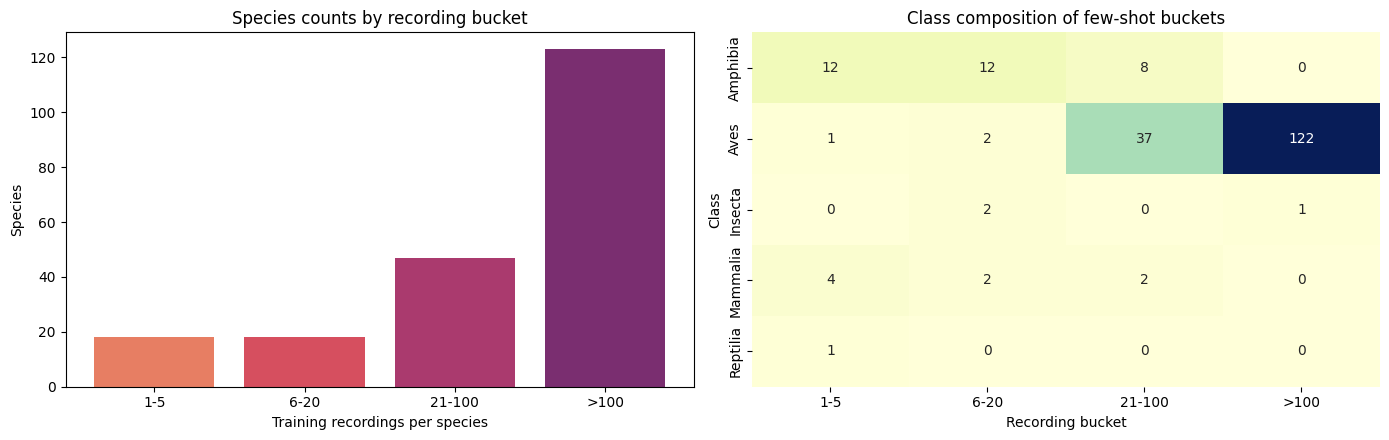

In [26]:
species_counts = (
    train_meta.groupby(['primary_label', 'common_name', 'class_name'], dropna=False)
    .size()
    .rename('n_recordings')
    .reset_index()
)
species_counts['display_name'] = species_counts['common_name'].fillna(species_counts['primary_label'])
BUCKET_ORDER = ['1-5', '6-20', '21-100', '>100']
species_counts['bucket'] = pd.cut(
    species_counts['n_recordings'],
    bins=[0, 5, 20, 100, np.inf],
    labels=BUCKET_ORDER,
    include_lowest=True,
)

fewshot_bucket_counts = species_counts['bucket'].value_counts().reindex(BUCKET_ORDER, fill_value=0)
class_bucket = (
    species_counts.groupby(['class_name', 'bucket'], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=BUCKET_ORDER, fill_value=0)
)
class_bucket = class_bucket.reindex([c for c in ['Amphibia', 'Aves', 'Insecta', 'Mammalia', 'Reptilia'] if c in class_bucket.index])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(fewshot_bucket_counts.index.astype(str), fewshot_bucket_counts.values, color=sns.color_palette('flare', len(BUCKET_ORDER)))
axes[0].set_title('Species counts by recording bucket')
axes[0].set_xlabel('Training recordings per species')
axes[0].set_ylabel('Species')

sns.heatmap(class_bucket, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[1])
axes[1].set_title('Class composition of few-shot buckets')
axes[1].set_xlabel('Recording bucket')
axes[1].set_ylabel('Class')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '03d_few_shot_species_buckets.png', dpi=120, bbox_inches='tight')
plt.show()


In [27]:
fewshot_examples = (
    species_counts.loc[species_counts['bucket'] == '1-5', ['display_name', 'class_name', 'n_recordings']]
    .sort_values(['n_recordings', 'display_name'])
    .head(12)
    .rename(columns={'display_name': 'species', 'class_name': 'class', 'n_recordings': 'recordings'})
)

print('Species per bucket')
display(fewshot_bucket_counts.rename('species').to_frame())
print('Class by bucket')
display(class_bucket)
print('Few-shot examples')
display(fewshot_examples)


Species per bucket


,species
bucket,
1-5,18
6-20,18
21-100,47
>100,123


Class by bucket


bucket,1-5,6-20,21-100,>100
class_name,,,,
Amphibia,12,12,8,0
Aves,1,2,37,122
Insecta,0,2,0,1
Mammalia,4,2,2,0
Reptilia,1,0,0,0


Few-shot examples


,species,class,recordings
12,Central Dwarf Frog,Amphibia,1
29,Hooded Capuchin,Mammalia,1
1,Southern Spectacled Caiman,Reptilia,1
16,Waxy Monkey Tree Frog,Amphibia,1
39,Cei's White-lipped Frog,Amphibia,2
4,Feral Horse,Mammalia,2
20,Mato Grosso Snouted Tree Frog,Amphibia,2
42,Black-tailed Marmoset,Mammalia,3
28,Cuyaba Dwarf Frog,Amphibia,3
23,Muller's Termite Frog,Amphibia,3


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The label tail becomes clearer when species are grouped by how many recordings they actually have. The corpus contains <strong>18 species</strong> with only <strong>1 to 5 clips</strong>, another <strong>18</strong> with <strong>6 to 20</strong>, <strong>47</strong> in the <strong>21 to 100</strong> range, and a dominant head of <strong>123 species</strong> with more than <strong>100 recordings</strong>. The imbalance is therefore not only a long tail. It is a split between a very large, well-covered head and a much smaller but still meaningful few-shot minority.</p>

<p style="color: #333;">That minority is also class-skewed. The rarest bucket is dominated by <strong>Amphibia</strong>, with species such as <strong>Central Dwarf Frog</strong>, <strong>Waxy Monkey Tree Frog</strong>, and <strong>Cei's White-lipped Frog</strong>, while the <strong>&gt;100</strong> bucket is almost entirely <strong>Aves</strong>. Any training recipe that samples only by clip count will therefore overfit the bird head first. <strong>Bucket-aware sampling</strong>, <strong>class-balanced loss</strong>, or a light <strong>rare-class upweighting</strong> scheme is more defensible than treating the whole label space as evenly observed.</p>

</div>


### Secondary Labels


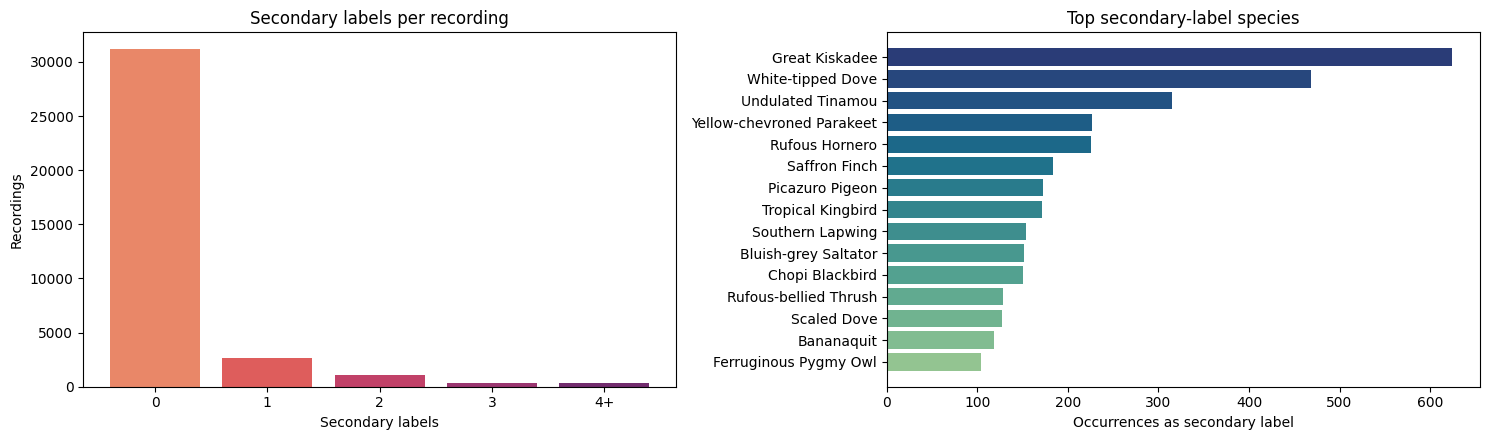

In [28]:
secondary_name_map = taxonomy.set_index('primary_label')['common_name']

def parse_secondary_labels(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        parsed = x
    else:
        try:
            parsed = ast.literal_eval(x)
        except Exception:
            return []
    if not isinstance(parsed, list):
        return []
    return [str(label).strip() for label in parsed if str(label).strip()]

secondary_lists = train_meta['secondary_labels'].apply(parse_secondary_labels)
secondary_per_record = secondary_lists.apply(len)
secondary_plot = secondary_per_record.clip(upper=4).value_counts().reindex([0, 1, 2, 3, 4], fill_value=0)
secondary_counts = pd.Series(Counter(label for labels in secondary_lists for label in labels)).sort_values(ascending=False)
secondary_display = secondary_counts.head(15).rename(index=lambda x: secondary_name_map.get(x, x))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].bar(['0', '1', '2', '3', '4+'], secondary_plot.values, color=sns.color_palette('flare', 5))
axes[0].set_title('Secondary labels per recording')
axes[0].set_xlabel('Secondary labels')
axes[0].set_ylabel('Recordings')

axes[1].barh(secondary_display.index[::-1], secondary_display.values[::-1], color=sns.color_palette('crest', len(secondary_display)))
axes[1].set_title('Top secondary-label species')
axes[1].set_xlabel('Occurrences as secondary label')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '03e_secondary_labels.png', dpi=120, bbox_inches='tight')
plt.show()


In [29]:
secondary_species = set(secondary_counts.index)
secondary_summary = pd.Series({
    'recordings_with_secondary': int((secondary_per_record > 0).sum()),
    'total_secondary_occurrences': int(secondary_counts.sum()),
    'unique_secondary_species': int(len(secondary_species)),
    'seen_as_both_primary_and_secondary': int(len(secondary_species & set(train_meta['primary_label'].unique()))),
}, name='value').to_frame()
secondary_per_record_table = pd.Series(
    {'0': int(secondary_plot.loc[0]), '1': int(secondary_plot.loc[1]), '2': int(secondary_plot.loc[2]), '3': int(secondary_plot.loc[3]), '4+': int(secondary_plot.loc[4])},
    name='recordings'
).to_frame()
secondary_examples = (
    secondary_display.head(12)
    .rename_axis('species')
    .reset_index(name='occurrences')
)

print('Secondary-label summary')
display(secondary_summary)
print('Secondary labels per recording')
display(secondary_per_record_table)
print('Top secondary species')
display(secondary_examples)


Secondary-label summary


,value
recordings_with_secondary,4372
total_secondary_occurrences,7431
unique_secondary_species,161
seen_as_both_primary_and_secondary,161


Secondary labels per recording


,recordings
0,31177
1,2623
2,1049
3,379
4+,321


Top secondary species


,species,occurrences
0,Great Kiskadee,624
1,White-tipped Dove,468
2,Undulated Tinamou,315
3,Yellow-chevroned Parakeet,226
4,Rufous Hornero,225
5,Saffron Finch,183
6,Picazuro Pigeon,172
7,Tropical Kingbird,171
8,Southern Lapwing,154
9,Bluish-grey Saltator,151


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The secondary-label column is large enough to matter. <strong>4,372 recordings</strong> contain at least one secondary label, producing <strong>7,431 total background occurrences</strong> across <strong>161 species</strong>. Most clips still have none, <strong>31,177</strong> remain at zero, but the non-empty subset is too large to treat as a curiosity or to discard without cost.</p>

<p style="color: #333;">The background layer also overlaps strongly with the main label space. The same <strong>161 species</strong> appear as both primary and secondary labels, and frequent background names such as <strong>Great Kiskadee</strong>, <strong>White-tipped Dove</strong>, and <strong>Undulated Tinamou</strong> are common enough to shape confusion patterns. That makes <strong>soft targets</strong>, <strong>background-aware loss weighting</strong>, or <strong>secondary-label regularization</strong> more appropriate than a strictly single-positive interpretation of every training clip.</p>

</div>


---

## Soundscape

In [30]:
def parse_labels(x):
    if pd.isna(x): return []
    return [t.strip() for t in str(x).split(';') if t.strip()]

### Structure

In [31]:
sc_exploded = soundscape_lbls.copy()
sc_exploded['primary_label'] = sc_exploded['primary_label'].str.split(';')
sc_exploded = sc_exploded.explode('primary_label')
sc_exploded['primary_label'] = sc_exploded['primary_label'].str.strip()
sc_exploded = sc_exploded.merge(
    taxonomy[['primary_label', 'common_name', 'class_name']],
    on='primary_label',
    how='left',
)
sc_exploded['display_name'] = sc_exploded['common_name'].fillna(sc_exploded['primary_label'])

labels_per_seg = soundscape_lbls['primary_label'].apply(lambda x: len(parse_labels(x)))
species_freq = sc_exploded['primary_label'].value_counts()
species_names = (
    sc_exploded[['primary_label', 'display_name', 'class_name']]
    .drop_duplicates()
    .set_index('primary_label')
)

top_named = pd.DataFrame([
    {
        'species': species_names.loc[label, 'display_name'],
        'class_name': species_names.loc[label, 'class_name'],
        'segments': int(count),
    }
    for label, count in species_freq.head(10).items()
])

soundscape_structure = pd.Series({
    'Unique species in soundscape labels': sc_exploded['primary_label'].nunique(),
    'Mean species per segment': round(labels_per_seg.mean(), 2),
    'Mode species per segment': int(labels_per_seg.mode()[0]),
    'Max species per segment': int(labels_per_seg.max()),
}, name='value').to_frame()

print('Soundscape structure summary')
display(soundscape_structure)
print('Top soundscape species')
display(top_named)


Soundscape structure summary


,value
Unique species in soundscape labels,75.00
Mean species per segment,4.22
Mode species per segment,4.00
Max species per segment,10.00


Top soundscape species


,species,class_name,segments
0,Dwarf Tree Frog,Amphibia,333
1,Southern Orange-legged Leaf Frog,Amphibia,313
2,Whistling Grass Frog,Amphibia,213
3,Chaco Tree Frog,Amphibia,210
4,Pale-legged Weeping Frog,Amphibia,175
5,Lesser Snouted Tree Frog,Amphibia,173
6,Mato Grosso Snouted Tree Frog,Amphibia,172
7,Marbled White-lipped Frog,Amphibia,155
8,Paraguayan Swimming Frog,Amphibia,149
9,Insect sonotype25,Insecta,84


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">After deduplication, the soundscape labels contain <strong>739 unique segments</strong> spanning <strong>75 species</strong>. Segment density still centers on <strong>four simultaneous labels</strong>, the mean is <strong>4.22</strong>, the range runs from <strong>1 to 10</strong>, and only <strong>78 segments</strong> contain a single species. The distribution remains <strong>highly imbalanced</strong>, with <strong>62 species</strong> appearing fewer than <strong>50 times</strong>.</p>

<p style="color: #333;">The dominant soundscape core is also <strong>heavily frog-weighted</strong>. The five most frequent labels are <strong>Dwarf Tree Frog</strong>, <strong>Southern Orange-legged Leaf Frog</strong>, <strong>Whistling Grass Frog</strong>, <strong>Chaco Tree Frog</strong>, and <strong>Pale-legged Weeping Frog</strong>, all within <strong>Amphibia</strong>. Bird species such as <strong>Chaco Chachalaca</strong> and <strong>White-tipped Dove</strong> appear later in the ranking, so the baseline multilabel setting is shaped first by <strong>nocturnal frog chorus structure</strong> and only then by bird events.</p>

</div>

### Species Coverage by Source

In [32]:
sc_species = set(lbl for x in soundscape_lbls['primary_label'] for lbl in parse_labels(x))
audio_species = set(train_meta['primary_label'].unique())
name_map = taxonomy.set_index('primary_label')['common_name'].to_dict()

soundscape_only = sorted(sc_species - audio_species)
soundscape_only_named = pd.DataFrame({
    'species': [name_map.get(label, label) for label in soundscape_only],
    'label': soundscape_only,
})
coverage_gap_summary = pd.Series({
    'Soundscape-only species': len(soundscape_only),
    'Train-audio-only species': len(audio_species - sc_species),
}, name='count').to_frame()

print('Coverage gap summary')
display(coverage_gap_summary)
print('Soundscape-only species')
display(soundscape_only_named)


Coverage gap summary


,count
Soundscape-only species,28
Train-audio-only species,159


Soundscape-only species


,species,label
0,Guaraní leaf-litter frog,1491113
1,Chiasmocleis mehelyi,25073
2,Insect sonotype01,47158son01
3,Insect sonotype02,47158son02
4,Insect sonotype03,47158son03
5,Insect sonotype04,47158son04
6,Insect sonotype05,47158son05
7,Insect sonotype06,47158son06
8,Insect sonotype07,47158son07
9,Insect sonotype08,47158son08


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">Coverage is <strong>asymmetric</strong> across the two sources. Of the <strong>75 species</strong> that appear in the soundscape labels, <strong>47</strong> also appear in <code>train_audio</code> and <strong>28</strong> are <strong>soundscape-only</strong>. That gap includes <strong>Guaraní leaf-litter frog</strong>, <strong>Chiasmocleis mehelyi</strong>, <strong>Southern Orange-legged Leaf Frog</strong>, and the full block of <strong>Insect sonotype01 through Insect sonotype25</strong>. Those classes are the <strong>highest-risk labels</strong> because they cannot be learned from isolated recordings.</p>

<p style="color: #333;">The opposite gap also matters. Another <strong>159 <code>train_audio</code> species</strong> never appear in the soundscape labels, so they must transfer into the Pantanal soundscape domain without direct multilabel supervision. The source mismatch therefore runs in both directions, but the <strong>frog- and insect-heavy soundscape-only classes</strong> are the sharpest blind spot.</p>

</div>

In [33]:
def parse_soundscape_filename(filename: str) -> dict:
    stem = filename.replace('.ogg', '')
    parts = stem.split('_')
    site = next((p for p in parts if p.startswith('S') and p[1:].isdigit()), None)
    date_str = parts[-2]
    time_str = parts[-1]
    return {
        'site': site,
        'hour': int(time_str[:2]),
        'month': int(date_str[4:6]),
    }

ss_meta = soundscape_lbls.copy()
meta_df = ss_meta['filename'].apply(parse_soundscape_filename).apply(pd.Series)
ss_meta = pd.concat([ss_meta, meta_df], axis=1)
ss_meta['label_list'] = ss_meta['primary_label'].apply(parse_labels)
ss_meta['n_labels'] = ss_meta['label_list'].apply(len)

ss_expanded = ss_meta.explode('label_list').rename(columns={'label_list': 'label'})
ss_expanded['label'] = ss_expanded['label'].str.strip()
ss_expanded = ss_expanded.merge(
    taxonomy[['primary_label', 'common_name', 'class_name']],
    left_on='label',
    right_on='primary_label',
    how='left',
)
ss_expanded['display_name'] = ss_expanded['common_name'].fillna(ss_expanded['label'])

soundscape_meta_summary = pd.Series({
    'Soundscape rows (deduped)': len(ss_meta),
    'Soundscape files': ss_meta['filename'].nunique(),
    'Number of sites': ss_meta['site'].dropna().nunique(),
    'Number of active hours': ss_meta['hour'].dropna().nunique(),
}, name='value').to_frame()
site_hour_catalog = pd.DataFrame({
    'sites': pd.Series(sorted(ss_meta['site'].dropna().unique().tolist())),
    'hours': pd.Series(sorted(ss_meta['hour'].dropna().unique().tolist())),
})

print('Soundscape metadata summary')
display(soundscape_meta_summary)
print('Observed sites and hours')
display(site_hour_catalog)


Soundscape metadata summary


,value
Soundscape rows (deduped),739
Soundscape files,66
Number of sites,9
Number of active hours,13


Observed sites and hours


,sites,hours
0,S03,0
1,S08,1
2,S09,2
3,S13,3
4,S15,4
5,S18,6
6,S19,7
7,S22,18
8,S23,19
9,NaN,20


### Coverage by Site and Hour

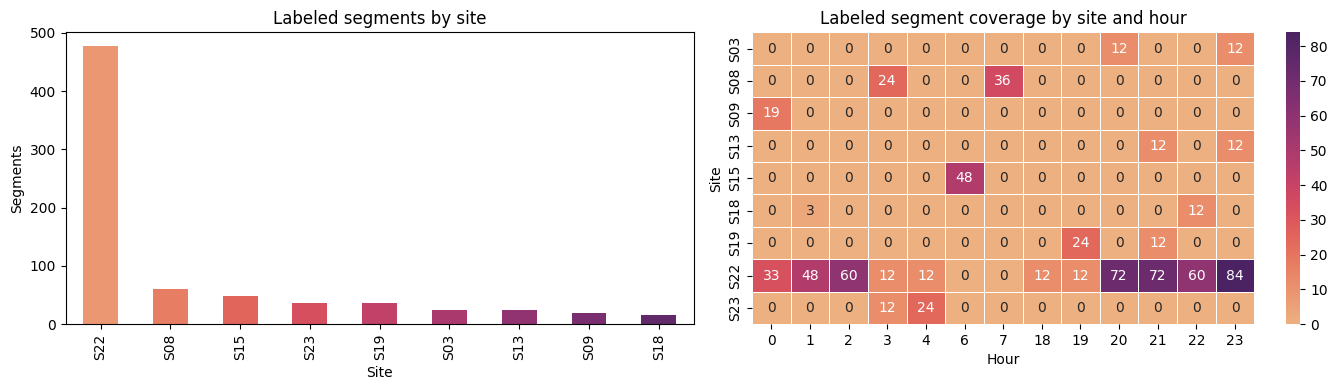

In [34]:
site_counts = ss_meta.groupby('site').size().sort_values(ascending=False)
hour_counts = ss_meta.groupby('hour').size().sort_values(ascending=False)
site_hour = ss_meta.pivot_table(index='site', columns='hour', values='filename', aggfunc='count', fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
site_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('flare', len(site_counts)))
axes[0].set_title('Labeled segments by site')
axes[0].set_xlabel('Site')
axes[0].set_ylabel('Segments')

sns.heatmap(site_hour, cmap='flare', annot=True, fmt='d', linewidths=0.5, ax=axes[1])
axes[1].set_title('Labeled segment coverage by site and hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Site')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '07_soundscape_site_hour_coverage.png', dpi=120, bbox_inches='tight')
plt.show()

In [35]:
top_site_hour = (
    site_hour.stack()
    .sort_values(ascending=False)
    .head(5)
    .rename('segments')
    .reset_index()
    .rename(columns={'site': 'site', 'hour': 'hour'})
)
site_hour_summary = pd.Series({
    'Covered site-hour cells': int((site_hour > 0).sum().sum()),
    'Largest site-hour cell': int(site_hour.values.max()),
    'Site-hour grid rows': int(site_hour.shape[0]),
    'Site-hour grid columns': int(site_hour.shape[1]),
}, name='value').to_frame()

print('Segments by site')
display(site_counts.rename('segments').to_frame())
print('Segments by hour')
display(hour_counts.rename('segments').to_frame())
print('Site-hour coverage summary')
display(site_hour_summary)
print('Top site-hour cells')
display(top_site_hour)


Segments by site


,segments
site,
S22,477
S08,60
S15,48
S23,36
S19,36
S03,24
S13,24
S09,19
S18,15


Segments by hour


,segments
hour,
23,108
21,96
20,84
22,72
2,60
0,52
1,51
6,48
3,48


Site-hour coverage summary


,value
Covered site-hour cells,25
Largest site-hour cell,84
Site-hour grid rows,9
Site-hour grid columns,13


Top site-hour cells


,site,hour,segments
0,S22,23,84
1,S22,20,72
2,S22,21,72
3,S22,2,60
4,S22,22,60


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">Coverage is <strong>highly uneven</strong>. Site <strong><code>S22</code></strong> alone contributes <strong>477 labeled segments</strong>, while the next-largest site contributes only <strong>60</strong>. The heatmap also shows that <strong><code>S22</code></strong> is not one continuous block. It splits into an early cluster around <strong>0 to 4</strong> and a second cluster around <strong>18 to 23</strong>, whereas most other sites look more like isolated snapshots than full recorder-hour coverage.</p>

<p style="color: #333;">The same concentration appears in time coverage, where <strong>hour 23</strong> contributes <strong>108 segments</strong> and only <strong>25 of the 117</strong> possible site-hour cells contain any labels at all. The priors derived from this matrix therefore have real support in a few recorder-hour combinations and only weak support elsewhere.</p>

</div>

### Fully-labeled vs Partially-labeled Files

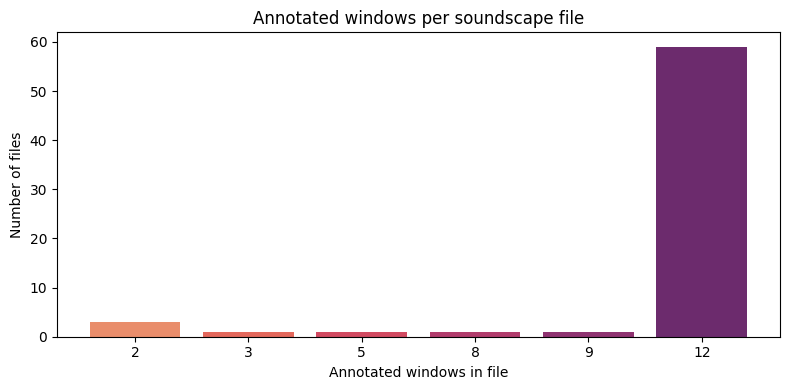

In [36]:
file_counts = ss_meta.groupby('filename').size().sort_values()
file_count_dist = file_counts.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(file_count_dist.index.astype(str), file_count_dist.values, color=sns.color_palette('flare', len(file_count_dist)))
ax.set_title('Annotated windows per soundscape file')
ax.set_xlabel('Annotated windows in file')
ax.set_ylabel('Number of files')
plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '12_fully_vs_partially_labeled_files.png', dpi=120, bbox_inches='tight')
plt.show()

In [37]:
full_files = int((file_counts == 12).sum())
partial_files = int((file_counts < 12).sum())
partial_examples = (
    file_counts[file_counts < 12]
    .rename('labeled_windows')
    .rename_axis('filename')
    .reset_index()
    .sort_values(['labeled_windows', 'filename'])
)
full_partial_summary = pd.Series({
    'Fully-labeled files': full_files,
    'Partially-labeled files': partial_files,
}, name='count').to_frame()

print('Window-count distribution')
display(file_count_dist.rename('files').to_frame())
print('Full vs partial file summary')
display(full_partial_summary)
print('Partial file examples')
display(partial_examples)


Window-count distribution


,files
2,3
3,1
5,1
8,1
9,1
12,59


Full vs partial file summary


,count
Fully-labeled files,59
Partially-labeled files,7


Partial file examples


,filename,labeled_windows
0,BC2026_Train_0006_S09_20250828_000000.ogg,2
1,BC2026_Train_0009_S09_20250828_000000.ogg,2
2,BC2026_Train_0010_S09_20250828_000000.ogg,2
3,BC2026_Train_0015_S18_20211016_011500.ogg,3
4,BC2026_Train_0008_S09_20250831_000000.ogg,5
5,BC2026_Train_0007_S09_20250829_000000.ogg,8
6,BC2026_Train_0026_S22_20211128_004500.ogg,9


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The labeled subset is mostly clean but not uniform. <strong>Fifty-nine files</strong> contain the full set of <strong>12 annotated windows</strong>, while <strong>7 files</strong> are only partially labeled, with counts ranging from <strong>2 to 9 windows</strong>. Any validation or prior-fitting procedure that assumes complete coverage should therefore be built from the <strong>59 trusted files</strong> rather than from the full <strong>66-file set</strong>.</p>

</div>

---

The next blocks shift from baseline label summaries to recorder-aware and time-aware soundscape EDA. Each interpretation is paired with a small validation block so the narrative rests on explicit counts rather than on plot inspection alone.

This section extends the baseline EDA with recorder-aware, time-aware, and species-level soundscape analyses. Each interpretation is paired with a validation block so the narrative rests on exact counts rather than on visual impression alone.

---

### Temporal Activity by Hour

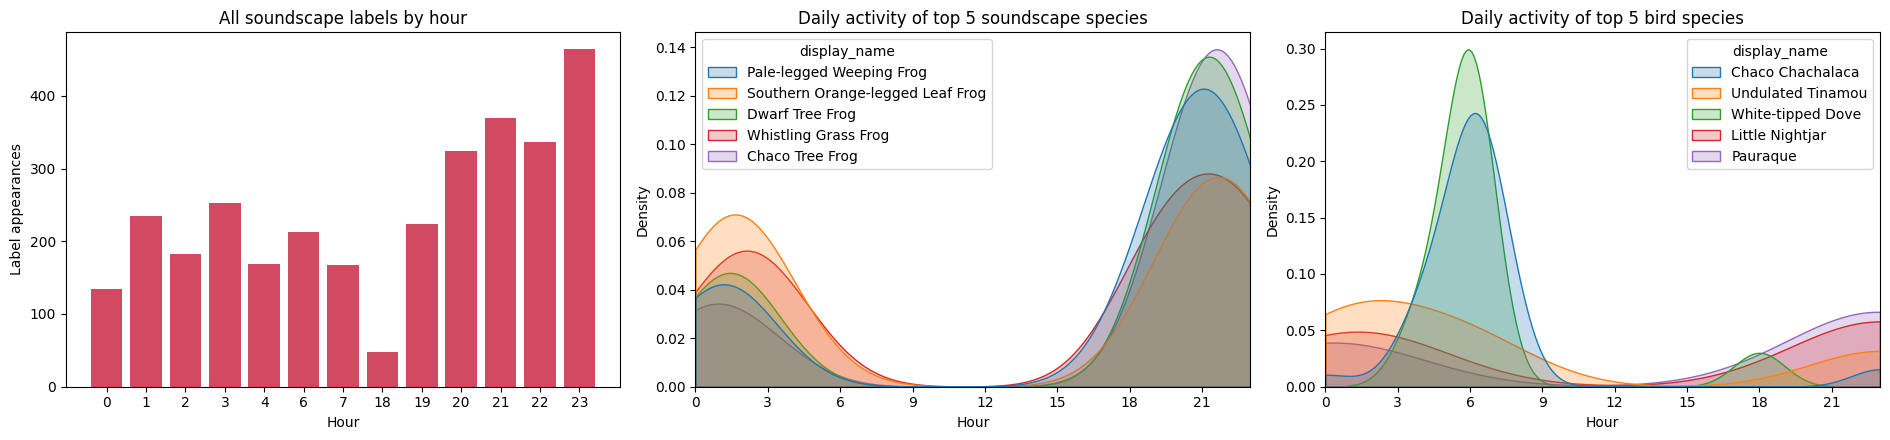

In [38]:
hour_activity = ss_expanded.groupby('hour').size().sort_index()
class_hour = (
    ss_expanded[ss_expanded['class_name'].isin(['Aves', 'Amphibia'])]
    .groupby(['hour', 'class_name'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
top_soundscape_species = ss_expanded['display_name'].value_counts().head(5).index.tolist()
top_soundscape_activity = ss_expanded[ss_expanded['display_name'].isin(top_soundscape_species)].copy()

bird_activity = ss_expanded[ss_expanded['class_name'] == 'Aves'].copy()
top_bird_species = bird_activity['display_name'].value_counts().head(5).index.tolist()
top_bird_activity = bird_activity[bird_activity['display_name'].isin(top_bird_species)].copy()

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
axes[0].bar(hour_activity.index.astype(str), hour_activity.values, color=PALETTE[2])
axes[0].set_title('All soundscape labels by hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Label appearances')

sns.kdeplot(
    data=top_soundscape_activity,
    x='hour',
    hue='display_name',
    common_norm=False,
    fill=True,
    bw_adjust=0.7,
    clip=(0, 23),
    ax=axes[1],
)
axes[1].set_title('Daily activity of top 5 soundscape species')

sns.kdeplot(
    data=top_bird_activity,
    x='hour',
    hue='display_name',
    common_norm=False,
    fill=True,
    bw_adjust=0.7,
    clip=(0, 23),
    ax=axes[2],
)
axes[2].set_title('Daily activity of top 5 bird species')

for ax in axes[1:]:
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel('Hour')
    ax.set_ylabel('Density')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '08_temporal_activity_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()

In [39]:
all_hour_top = ss_expanded.groupby('hour').size().sort_values(ascending=False)
aves_hour_top = ss_expanded[ss_expanded['class_name'] == 'Aves'].groupby('hour').size().sort_values(ascending=False)
amph_hour_top = ss_expanded[ss_expanded['class_name'] == 'Amphibia'].groupby('hour').size().sort_values(ascending=False)
top_soundscape_profiles = {
    name: top_soundscape_activity[top_soundscape_activity['display_name'] == name].groupby('hour').size().to_dict()
    for name in top_soundscape_species
}
top_bird_profiles = {
    name: top_bird_activity[top_bird_activity['display_name'] == name].groupby('hour').size().to_dict()
    for name in top_bird_species
}

top_overall_hours = all_hour_top.head(5).rename('segments').to_frame()
top_aves_hours = aves_hour_top.head(5).rename('segments').to_frame()
top_amph_hours = amph_hour_top.head(5).rename('segments').to_frame()
top_overall_species = ss_expanded['display_name'].value_counts().head(5).rename_axis('species').reset_index(name='segments')
top_bird_species_table = bird_activity['display_name'].value_counts().head(5).rename_axis('species').reset_index(name='segments')
top_soundscape_profile_df = pd.DataFrame(top_soundscape_profiles).fillna(0).astype(int).sort_index()
top_bird_profile_df = pd.DataFrame(top_bird_profiles).fillna(0).astype(int).sort_index()

print('Top overall hours')
display(top_overall_hours)
print('Top Aves hours')
display(top_aves_hours)
print('Top Amphibia hours')
display(top_amph_hours)
print('Top overall soundscape species')
display(top_overall_species)
print('Top bird species')
display(top_bird_species_table)
print('Hour profiles for top soundscape species')
display(top_soundscape_profile_df)
print('Hour profiles for top bird species')
display(top_bird_profile_df)


Top overall hours


,segments
hour,
23,464
21,370
22,337
20,324
3,252


Top Aves hours


,segments
hour,
6,160
23,84
1,31
4,31
18,28


Top Amphibia hours


...

,species,segments
0,Chaco Chachalaca,65
1,White-tipped Dove,63
2,Undulated Tinamou,43
3,Pauraque,38
4,Little Nightjar,37


Hour profiles for top soundscape species


,Dwarf Tree Frog,Southern Orange-legged Leaf Frog,Whistling Grass Frog,Chaco Tree Frog,Pale-legged Weeping Frog
0,12,17,7,18,5
1,31,43,12,13,24
2,30,53,32,0,12
3,9,12,12,12,0
4,0,12,12,0,0
18,0,0,0,0,2
19,0,7,32,0,12
20,66,44,36,30,36
21,84,23,0,48,30
22,48,42,14,48,36


Hour profiles for top bird species


,Chaco Chachalaca,White-tipped Dove,Undulated Tinamou,Pauraque,Little Nightjar
0,2,0,6,9,0
1,0,0,6,5,11
2,0,0,9,0,6
4,11,10,0,0,0
6,32,48,12,0,0
7,17,0,0,0,0
18,0,5,0,0,0
19,0,0,0,1,0
23,3,0,10,23,20


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">Daily activity separates <strong>frogs</strong> and <strong>birds</strong> more clearly than the aggregate histogram alone suggests. The five most frequent soundscape species are all frogs, and their profiles cluster after <strong>20:00</strong>. <strong>Dwarf Tree Frog</strong> peaks at <strong>21 with 84 appearances</strong>, <strong>Southern Orange-legged Leaf Frog</strong> peaks at <strong>23 with 60</strong>, and <strong>Chaco Tree Frog</strong> remains concentrated from <strong>20 to 23</strong>. The late-night windows are therefore shaped first by <strong>amphibian chorus structure</strong>, and the frog curves are relatively synchronized rather than spread evenly across the clock.</p>

<p style="color: #333;">The bird panel is less synchronized. It splits into a <strong>dawn-facing regime</strong>, led by <strong>White-tipped Dove</strong> with <strong>48 appearances at hour 6</strong> and <strong>Chaco Chachalaca</strong> with <strong>32</strong> at the same hour, and a smaller <strong>nocturnal regime</strong>, led by <strong>Pauraque</strong> and <strong>Little Nightjar</strong> around <strong>23</strong>. Time therefore acts as both a <strong>class prior</strong> and a <strong>species prior</strong>, which makes <strong>hour-aware filtering</strong> especially useful for suppressing implausible bird detections inside frog-dominated night windows.</p>

</div>

### Site-Specific Species

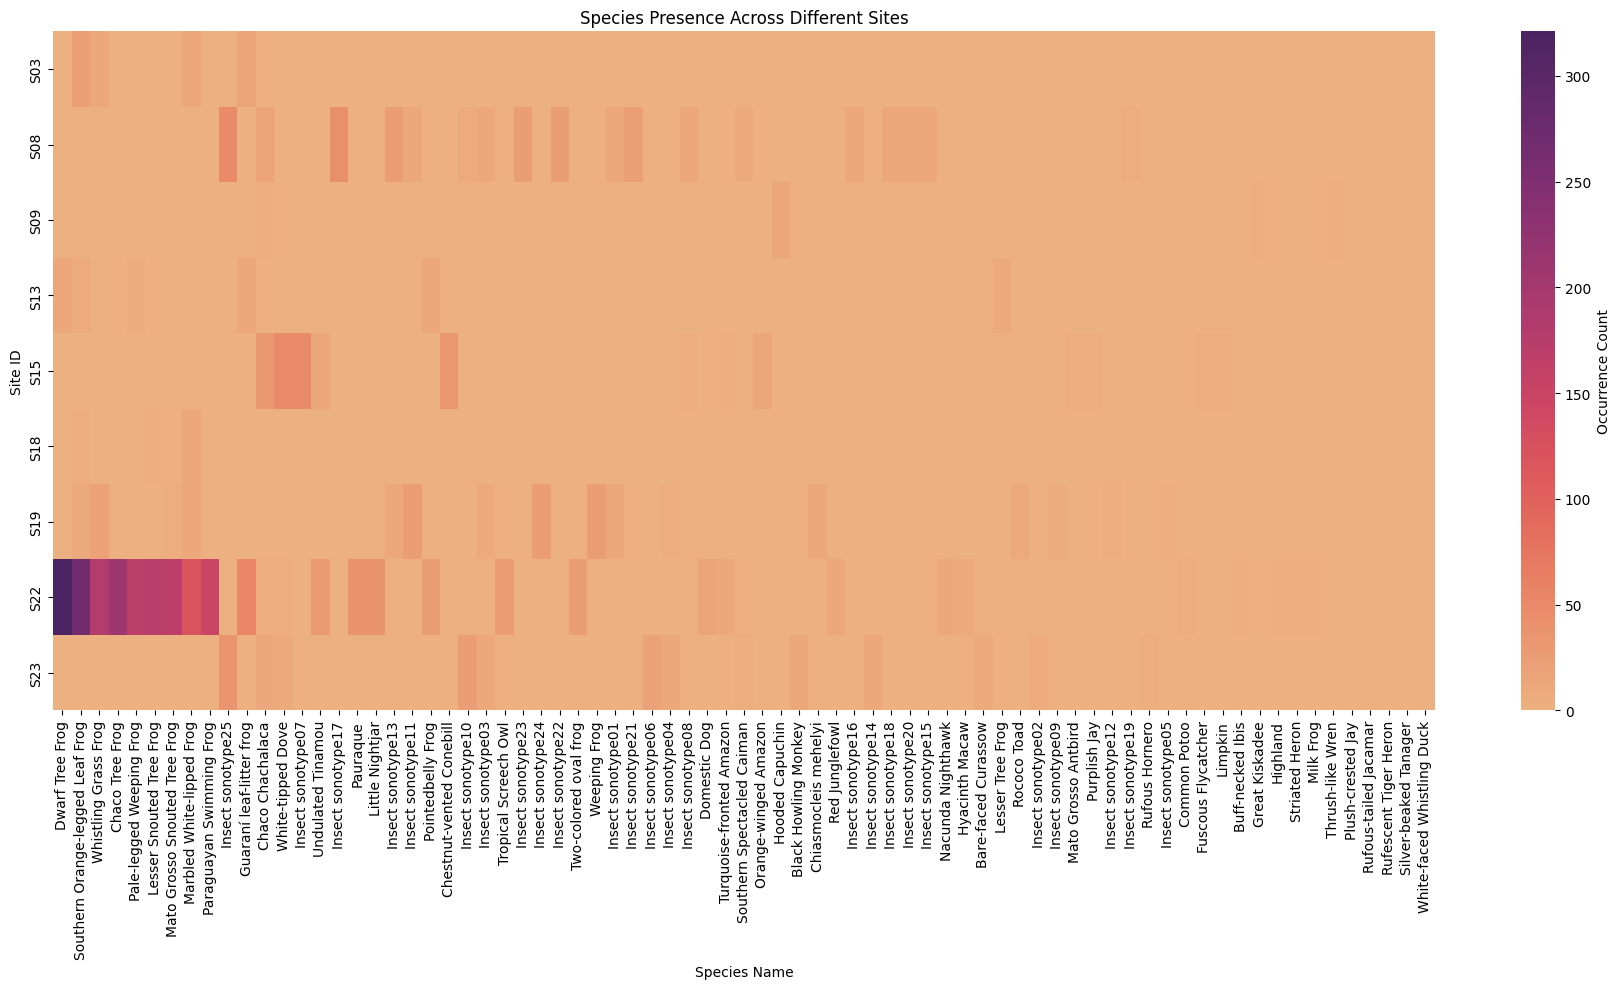

In [40]:
site_species = ss_expanded.groupby(['site', 'display_name']).size().unstack(fill_value=0)
site_species = site_species.loc[:, site_species.sum(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(site_species, cmap='flare', cbar_kws={'label': 'Occurrence Count'}, ax=ax)
ax.set_title('Species Presence Across Different Sites')
ax.set_xlabel('Species Name')
ax.set_ylabel('Site ID')
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '09_site_species_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [41]:
site_presence = (site_species > 0).astype(int)
unique_species_by_site = {}
for site in site_species.index:
    other_sites_sum = site_species.drop(site).sum(axis=0)
    unique_to_this_site = site_species.columns[(site_species.loc[site] > 0) & (other_sites_sum == 0)].tolist()
    unique_species_by_site[site] = unique_to_this_site

site_unique_counts = pd.Series({site: len(species) for site, species in unique_species_by_site.items()}).sort_values(ascending=False)

site_dominant_rows = []
for species in site_species.columns:
    total = int(site_species[species].sum())
    top_site = site_species[species].idxmax()
    top_count = int(site_species.loc[top_site, species])
    site_dominant_rows.append({
        'species': species,
        'top_site': top_site,
        'top_count': top_count,
        'total': total,
        'share': round(top_count / total, 3),
    })
site_dominant_rows = sorted(site_dominant_rows, key=lambda x: x['share'], reverse=True)

unique_species_examples = pd.DataFrame([
    {
        'site': site,
        'unique_species_count': len(species),
        'example_species': ', '.join(species[:6]) if species else '',
    }
    for site, species in unique_species_by_site.items()
]).sort_values(['unique_species_count', 'site'], ascending=[False, True])
site_dominant_df = pd.DataFrame(site_dominant_rows[:10])

print('Unique-species counts by site')
display(site_unique_counts.rename('species').to_frame())
print('Unique species examples by site')
display(unique_species_examples)
print('Most site-dominant species')
display(site_dominant_df)


Unique-species counts by site


,species
S22,14
S15,9
S08,9
S23,7
S19,6
S09,4
S13,1
S03,0
S18,0


Unique species examples by site


,site,unique_species_count,example_species
7,S22,14,"Paraguayan Swimming Frog, Little Nightjar, Tro..."
1,S08,9,"Insect sonotype17, Insect sonotype23, Insect s..."
4,S15,9,"Insect sonotype07, Chestnut-vented Conebill, O..."
8,S23,7,"Insect sonotype06, Black Howling Monkey, Insec..."
6,S19,6,"Insect sonotype24, Weeping Frog, Chiasmocleis ..."
2,S09,4,"Hooded Capuchin, Great Kiskadee, Thrush-like W..."
3,S13,1,Lesser Tree Frog
0,S03,0,
5,S18,0,


Most site-dominant species


,species,top_site,top_count,total,share
0,Paraguayan Swimming Frog,S22,149,149,1.0
1,Insect sonotype07,S15,48,48,1.0
2,Insect sonotype17,S08,43,43,1.0
3,Little Nightjar,S22,37,37,1.0
4,Chestnut-vented Conebill,S15,35,35,1.0
5,Tropical Screech Owl,S22,26,26,1.0
6,Insect sonotype23,S08,24,24,1.0
7,Insect sonotype24,S19,24,24,1.0
8,Insect sonotype22,S08,24,24,1.0
9,Two-colored oval frog,S22,24,24,1.0


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The heatmap shows that site composition is <strong>uneven</strong>, not uniformly shared across recorders. <strong><code>S22</code></strong> stands out most clearly: it has both the <strong>broadest visible spread of non-zero species</strong> and the <strong>darkest concentration</strong> in the left-side frog block. In the zoomed view, that cluster is driven by repeated detections of species such as <strong>Dwarf Tree Frog</strong>, <strong>Southern Orange-legged Leaf Frog</strong>, <strong>Whistling Grass Frog</strong>, <strong>Chaco Tree Frog</strong>, and <strong>Paraguayan Swimming Frog</strong>, all of which are markedly stronger at <strong><code>S22</code></strong> than at neighboring sites <strong><code>S19</code></strong> and <strong><code>S23</code></strong>.</p>

<p style="color: #333;">The contrast is therefore not just a generic increase in activity. <strong><code>S22</code></strong> appears to host a <strong>frog-heavy local soundscape profile</strong>, while sites such as <strong><code>S09</code></strong> remain sparse and sites such as <strong><code>S08</code></strong> and <strong><code>S15</code></strong> show narrower, more localized clusters. That supports using a <strong>site prior</strong> as a context feature for ranking plausible species. At the same time, this figure uses <strong>raw occurrence counts</strong>, so part of the intensity difference may reflect <strong>unequal site coverage</strong> rather than ecology alone.</p>

</div>

### Species Co-occurrence

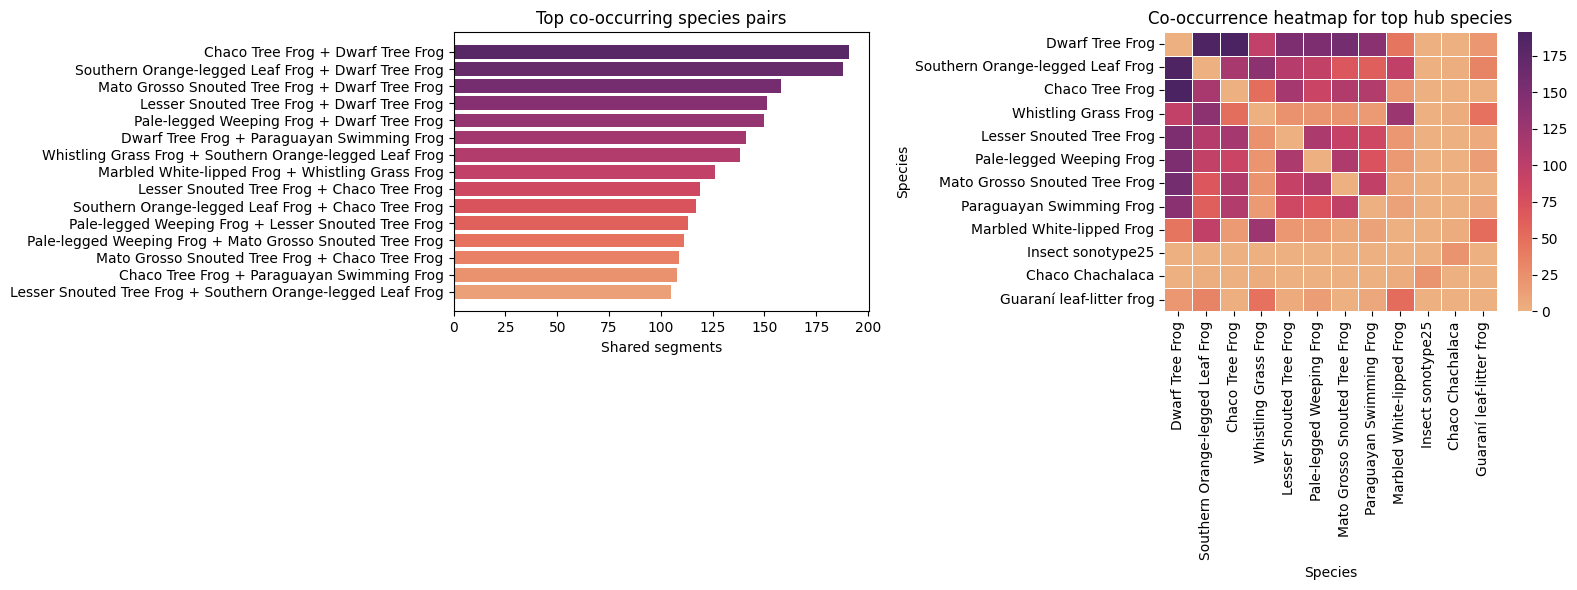

In [42]:
pair_counts = Counter()
for labels in ss_meta['label_list']:
    labs = sorted(set(labels))
    for a, b in combinations(labs, 2):
        pair_counts[(a, b)] += 1

label_name_map = ss_expanded[['label', 'display_name']].drop_duplicates().set_index('label')['display_name'].to_dict()
label_class_map = ss_expanded[['label', 'class_name']].drop_duplicates().set_index('label')['class_name'].to_dict()

pair_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counts.items()],
    columns=['label_a', 'label_b', 'count']
).sort_values('count', ascending=False)
pair_df['name_a'] = pair_df['label_a'].map(label_name_map).fillna(pair_df['label_a'])
pair_df['name_b'] = pair_df['label_b'].map(label_name_map).fillna(pair_df['label_b'])

hub_counts = Counter()
for (a, b), c in pair_counts.items():
    hub_counts[a] += c
    hub_counts[b] += c

top_species = [lab for lab, _ in hub_counts.most_common(12)]
top_species_named = [label_name_map.get(lab, lab) for lab in top_species]
co_mat = pd.DataFrame(0, index=top_species_named, columns=top_species_named, dtype=int)
for (a, b), c in pair_counts.items():
    if a in top_species and b in top_species:
        co_mat.loc[label_name_map.get(a, a), label_name_map.get(b, b)] = c
        co_mat.loc[label_name_map.get(b, b), label_name_map.get(a, a)] = c

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_pairs = pair_df.head(15).iloc[::-1]
axes[0].barh(
    [f'{a} + {b}' for a, b in zip(plot_pairs['name_a'], plot_pairs['name_b'])],
    plot_pairs['count'],
    color=sns.color_palette('flare', len(plot_pairs))
)
axes[0].set_title('Top co-occurring species pairs')
axes[0].set_xlabel('Shared segments')

sns.heatmap(co_mat, cmap='flare', linewidths=0.5, ax=axes[1])
axes[1].set_title('Co-occurrence heatmap for top hub species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Species')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '10_species_cooccurrence.png', dpi=120, bbox_inches='tight')
plt.show()

In [43]:
hub_named = [
    {
        'species': label_name_map.get(label, label),
        'class_name': label_class_map.get(label, 'Unknown'),
        'count': int(count),
    }
    for label, count in hub_counts.most_common(10)
]

top_pairs_df = pair_df[['name_a', 'name_b', 'count']].head(10).rename(columns={'name_a': 'species_a', 'name_b': 'species_b'})
hub_named_df = pd.DataFrame(hub_named)

print('Top co-occurring pairs')
display(top_pairs_df)
print('Top hub species')
display(hub_named_df)


Top co-occurring pairs


,species_a,species_b,count
18,Chaco Tree Frog,Dwarf Tree Frog,191
9,Southern Orange-legged Leaf Frog,Dwarf Tree Frog,188
8,Mato Grosso Snouted Tree Frog,Dwarf Tree Frog,158
27,Lesser Snouted Tree Frog,Dwarf Tree Frog,151
6,Pale-legged Weeping Frog,Dwarf Tree Frog,150
25,Dwarf Tree Frog,Paraguayan Swimming Frog,141
11,Whistling Grass Frog,Southern Orange-legged Leaf Frog,138
39,Marbled White-lipped Frog,Whistling Grass Frog,126
26,Lesser Snouted Tree Frog,Chaco Tree Frog,119
17,Southern Orange-legged Leaf Frog,Chaco Tree Frog,117


Top hub species


,species,class_name,count
0,Dwarf Tree Frog,Amphibia,1251
1,Southern Orange-legged Leaf Frog,Amphibia,1058
2,Chaco Tree Frog,Amphibia,834
3,Whistling Grass Frog,Amphibia,768
4,Lesser Snouted Tree Frog,Amphibia,754
5,Pale-legged Weeping Frog,Amphibia,749
6,Mato Grosso Snouted Tree Frog,Amphibia,729
7,Paraguayan Swimming Frog,Amphibia,629
8,Marbled White-lipped Frog,Amphibia,570
9,Insect sonotype25,Insecta,367


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">Co-occurrence is led by a <strong>frog chorus</strong> rather than by a balanced multispecies mix. The strongest pair is <strong>Chaco Tree Frog with Dwarf Tree Frog</strong>, <strong>191 shared segments</strong>, followed closely by <strong>Southern Orange-legged Leaf Frog with Dwarf Tree Frog</strong> at <strong>188</strong>. The leading hubs tell the same story. The <strong>nine most connected species</strong> are all amphibians, with <strong>Dwarf Tree Frog</strong> alone reaching cumulative pair frequency <strong>1,251</strong>.</p>

<p style="color: #333;">That makes the top of the co-occurrence table <strong>biologically structured</strong> rather than random overlap. The heatmap is also <strong>modular</strong>: the strongest block is almost entirely frog-frog, while non-frog species sit on the periphery with much weaker links. The late-night soundscape is therefore anchored by a <strong>stable frog core</strong>, so post-processing can use those recurring pairings as a <strong>consistency check</strong> instead of treating every multilabel combination as equally plausible.</p>

</div>

### Labels per Segment by Site and Hour

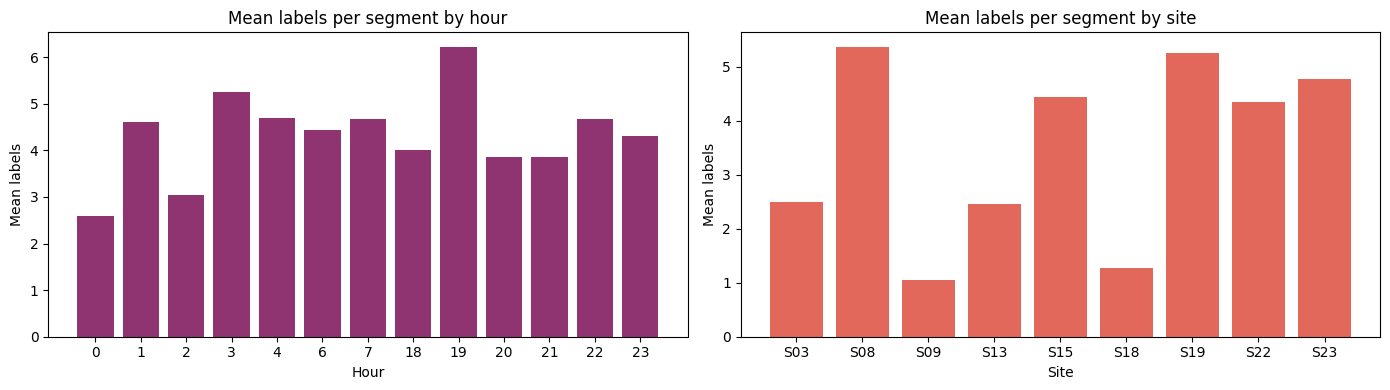

In [44]:
labels_by_hour = ss_meta.groupby('hour')['n_labels'].agg(['mean', 'median', 'max', 'count']).round(2)
labels_by_site = ss_meta.groupby('site')['n_labels'].agg(['mean', 'median', 'max', 'count']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(labels_by_hour.index.astype(str), labels_by_hour['mean'], color=PALETTE[4])
axes[0].set_title('Mean labels per segment by hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean labels')

axes[1].bar(labels_by_site.index.astype(str), labels_by_site['mean'], color=PALETTE[1])
axes[1].set_title('Mean labels per segment by site')
axes[1].set_xlabel('Site')
axes[1].set_ylabel('Mean labels')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '11_labels_per_segment_by_context.png', dpi=120, bbox_inches='tight')
plt.show()

In [45]:
print('Labels per segment by hour')
display(labels_by_hour.round(2))
print('Labels per segment by site')
display(labels_by_site.round(2))


Labels per segment by hour


,mean,median,max,count
hour,,,,
0,2.60,2.0,6,52
1,4.61,5.0,8,51
2,3.05,3.0,6,60
3,5.25,5.0,9,48
4,4.69,5.0,6,36
6,4.44,4.0,7,48
7,4.67,5.0,7,36
18,4.00,4.0,6,12
19,6.22,6.0,10,36


Labels per segment by site


,mean,median,max,count
site,,,,
S03,2.50,2.5,4,24
S08,5.37,6.0,9,60
S09,1.05,1.0,2,19
S13,2.46,2.0,5,24
S15,4.44,4.0,7,48
S18,1.27,1.0,3,15
S19,5.25,6.0,10,36
S22,4.34,4.0,8,477
S23,4.78,5.0,6,36


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">Overlap intensity changes with context. <strong>Hour 19</strong> has the highest mean multilabel density at <strong>6.22 labels per segment</strong>, while <strong>hour 23</strong> carries the largest raw label volume. The same distinction appears by site: <strong><code>S22</code></strong> has the most segments overall, but <strong><code>S08</code></strong> and <strong><code>S19</code></strong> are among the densest on a per-segment basis. Sites <strong><code>S08</code></strong>, <strong><code>S19</code></strong>, <strong><code>S22</code></strong>, and <strong><code>S23</code></strong> all average above <strong>4.3</strong> labels per segment, whereas <strong><code>S09</code></strong> and <strong><code>S18</code></strong> are sparse, nearly single-label environments.</p>

<p style="color: #333;">The notebook therefore should not treat <strong>coverage volume</strong> and <strong>multilabel difficulty</strong> as the same thing, or assume either one is uniform across the soundscape subset.</p>

</div>

---

## Train Audio

### Duration by Taxonomic Class

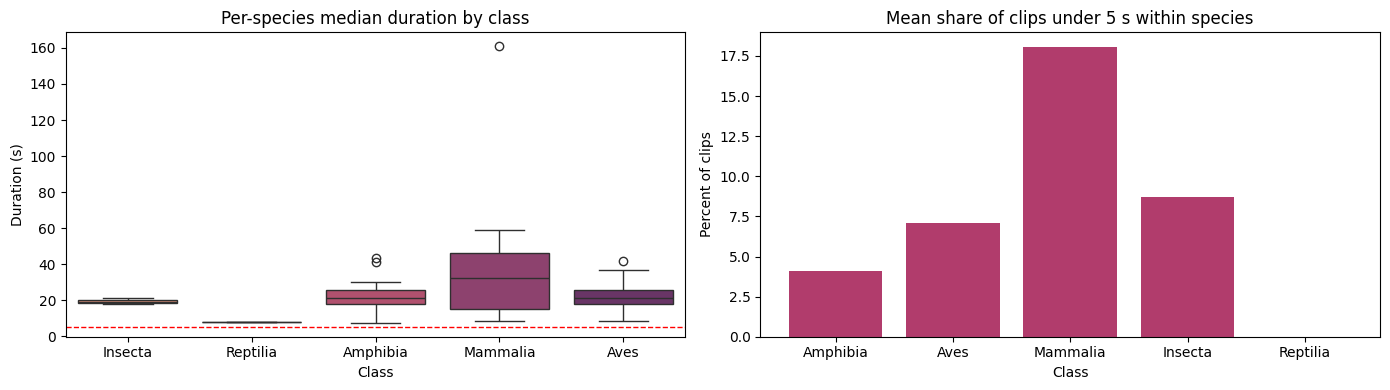

In [46]:
from concurrent.futures import ThreadPoolExecutor

cache_path = CFG.DUR_CACHE

def build_audio_path(filename):
    return str(CFG.BASE / 'train_audio' / filename)

def short_share_pct(series):
    return (series < 5).mean() * 100

if cache_path.exists():
    clip_duration_df = pd.read_csv(cache_path)
else:
    clip_duration_df = train_meta[['primary_label', 'filename', 'class_name', 'common_name']].copy()
    clip_duration_df['primary_label'] = clip_duration_df['primary_label'].astype(str)
    clip_duration_df['path'] = clip_duration_df['filename'].map(build_audio_path)

    def read_duration(path_str):
        info = sf.info(path_str)
        return info.frames / info.samplerate

    max_workers = min(32, max(4, (os.cpu_count() or 4) * 2))
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        clip_duration_df['duration'] = list(ex.map(read_duration, clip_duration_df['path']))

    clip_duration_df = clip_duration_df.drop(columns='path')
    clip_duration_df.to_csv(cache_path, index=False)

duration_df = clip_duration_df.groupby('primary_label', as_index=False).agg(
    class_name=('class_name', 'first'),
    common_name=('common_name', 'first'),
    n_clips=('duration', 'size'),
    duration_mean=('duration', 'mean'),
    duration_median=('duration', 'median'),
    duration_min=('duration', 'min'),
    duration_max=('duration', 'max'),
    short_share=('duration', short_share_pct),
)

plot_classes = ['Amphibia', 'Aves', 'Mammalia', 'Insecta', 'Reptilia']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(
    data=duration_df[duration_df['class_name'].isin(plot_classes)],
    x='class_name',
    y='duration_median',
    ax=axes[0],
    palette='flare',
)
axes[0].axhline(5, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Per-species median duration by class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Duration (s)')

lt5_by_class = (
    duration_df.groupby('class_name')['short_share']
    .mean()
    .reindex(plot_classes)
    .fillna(0)
)
axes[1].bar(lt5_by_class.index.astype(str), lt5_by_class.values, color=PALETTE[3])
axes[1].set_title('Mean share of clips under 5 s within species')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percent of clips')

plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '13_duration_by_class.png', dpi=120, bbox_inches='tight')
plt.show()


In [47]:
duration_stats = duration_df.groupby('class_name').agg(
    species_count=('primary_label', 'size'),
    clips_scanned=('n_clips', 'sum'),
    mean_species_median=('duration_median', 'mean'),
    median_species_median=('duration_median', 'median'),
    max_species_median=('duration_median', 'max'),
).round(2)
lt5_pct = duration_df.groupby('class_name')['short_share'].mean().round(1).rename('mean_short_share_pct').to_frame()

print('Duration stats by class, using all files then aggregating per species')
display(duration_stats)
print('Mean share of clips under 5 s within species')
display(lt5_pct)


Duration stats by class, using all files then aggregating per species


,species_count,clips_scanned,mean_species_median,median_species_median,max_species_median
class_name,,,,,
Amphibia,32,451,21.67,21.24,43.20
Aves,162,34799,21.84,21.03,41.98
Insecta,3,199,19.36,18.76,21.29
Mammalia,8,99,45.15,32.19,160.98
Reptilia,1,1,7.86,7.86,7.86


Mean share of clips under 5 s within species


,mean_short_share_pct
class_name,
Amphibia,4.1
Aves,7.1
Insecta,8.7
Mammalia,18.1
Reptilia,0.0


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The duration comparison is stronger when it is built from <strong>all available clips</strong> and then aggregated within each species. That prevents species with very large folders from dominating the class plot, while also avoiding the noise of a one-file shortcut. The class comparison therefore reflects <strong>species-level central tendency</strong> rather than raw corpus volume.</p>

<p style="color: #333;">Under that <strong>species-balanced view</strong>, the strongest signal is not a clean amphibian-versus-bird gap in central duration. <strong>Amphibia</strong> and <strong>Aves</strong> sit at almost the same species-level center, near <strong>21 seconds</strong>, but <strong>Aves</strong> carries a higher share of very short clips at <strong>7.1%</strong> versus <strong>4.1%</strong> for <strong>Amphibia</strong>, and it also shows a broader spread. <strong>Mammalia</strong> has the longest medians and widest variance, but only <strong>8 species</strong> contribute; <strong>Reptilia</strong> is a single-species case and should be interpreted cautiously.</p>

<p style="color: #333;">The modeling implication is therefore about <strong>clip structure</strong> more than a simple ranking of class medians. <strong>Repeat-padding</strong> and <strong>aggressive crop sampling</strong> remain more defensible for bird-heavy training because short clips are more common, while frog-rich audio still behaves more like <strong>repetitive texture</strong> than isolated events.</p>

</div>

### Spectrogram Archetypes

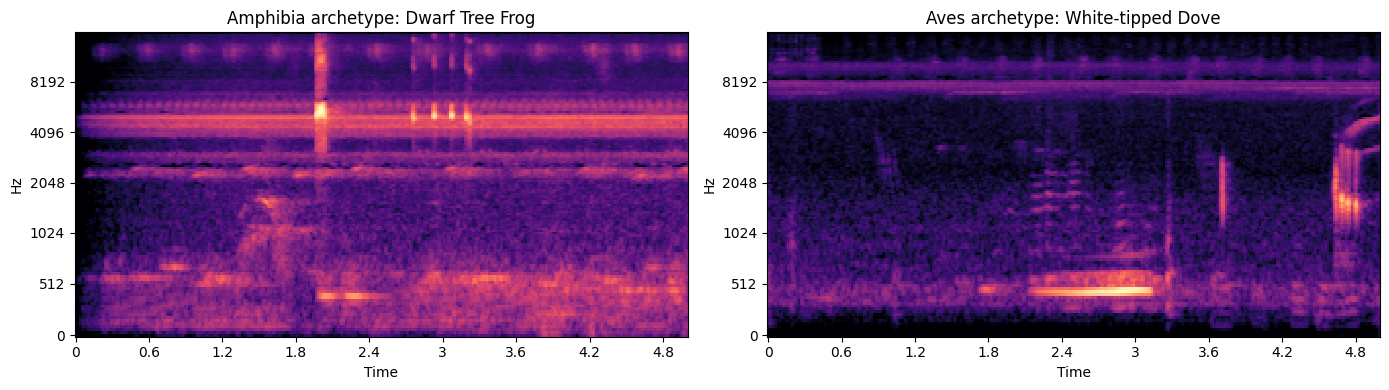

In [48]:
frog_label = '65380'      # Dwarf Tree Frog, reference archetype
bird_label = 'whtdov'     # White-tipped Dove, dawn-facing bird archetype

frog_path = sorted((CFG.BASE / 'train_audio' / frog_label).glob('*.ogg'))[0]
bird_path = sorted((CFG.BASE / 'train_audio' / bird_label).glob('*.ogg'))[0]

plot_sr = 32000

def load_mel_for_plot(path, sr=plot_sr, duration=5.0):
    y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
    if len(y) < sr * duration:
        y = np.tile(y, int(np.ceil(sr * duration / len(y))))[:int(sr * duration)]
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
    return librosa.power_to_db(S, ref=np.max)

frog_mel = load_mel_for_plot(frog_path)
bird_mel = load_mel_for_plot(bird_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
librosa.display.specshow(frog_mel, sr=plot_sr, x_axis='time', y_axis='mel', fmax=16000, ax=axes[0])
axes[0].set_title('Amphibia archetype: Dwarf Tree Frog')
librosa.display.specshow(bird_mel, sr=plot_sr, x_axis='time', y_axis='mel', fmax=16000, ax=axes[1])
axes[1].set_title('Aves archetype: White-tipped Dove')
plt.tight_layout()
fig.savefig(CFG.OUT_DIR / '14_spectrogram_archetypes.png', dpi=120, bbox_inches='tight')
plt.show()

In [49]:
frog_meta = duration_df.loc[
    duration_df['primary_label'] == frog_label,
    ['common_name', 'class_name', 'n_clips', 'duration_mean', 'duration_median']
].round({'duration_mean': 2, 'duration_median': 2}).iloc[0].to_dict()
bird_meta = duration_df.loc[
    duration_df['primary_label'] == bird_label,
    ['common_name', 'class_name', 'n_clips', 'duration_mean', 'duration_median']
].round({'duration_mean': 2, 'duration_median': 2}).iloc[0].to_dict()

spectro_examples = pd.DataFrame([
    {'role': 'frog', 'filename': frog_path.name, **frog_meta},
    {'role': 'bird', 'filename': bird_path.name, **bird_meta},
])

print('Spectrogram example metadata')
display(spectro_examples)


Spectrogram example metadata


,role,filename,common_name,class_name,n_clips,duration_mean,duration_median
0,frog,XC1066017.ogg,Dwarf Tree Frog,Amphibia,23,19.90,19.33
1,bird,XC1009285.ogg,White-tipped Dove,Aves,491,42.75,27.19


<div style="display:none">

#### Insights

</div>

<div style="padding: 15px 20px; border-left: 4px solid #28a745; background: #f0fff0; border-radius: 4px; max-width: 90%;">
<h4 style="color: #1a1a2a; margin-top: 0;">Insights</h4>

<p style="color: #333;">The contrast in spectrogram structure remains visible with the current representative species. <strong>Dwarf Tree Frog</strong> concentrates energy into a <strong>tighter and more repetitive band</strong>, whereas <strong>White-tipped Dove</strong> shows <strong>more separated vocal events</strong> with clearer gaps between calls. The class separation is therefore not only taxonomic. It is also <strong>acoustic</strong>.</p>

<p style="color: #333;">That distinction supports different handling downstream. <strong>Frog-rich soundscapes</strong> behave more like <strong>dense texture mixtures</strong>, while <strong>bird-rich clips</strong> behave more like <strong>sparse event sequences</strong>. Augmentation, cropping, and post-processing should therefore preserve the <strong>frogs-versus-birds split</strong> rather than forcing one uniform audio strategy across both groups.</p>

</div>


<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">

# Processing & Modeling Implications

<hr style="border: 0; border-top: 2px solid #4C8B8B; margin-top: 10px; width: 100%; max-width: 100%; box-sizing: border-box;">


The final step is to translate the EDA into pipeline components, so the notebook does not stop at description and starts informing actual design choices.

**Time-aware processing** should be added before final thresholding. The soundscape labels support **species-by-hour prevalence tables**, and the split between late-night frogs, dawn birds, and nocturnal birds is strong enough to justify **hour-conditioned priors**. In practice, that can be implemented as **logit offsets**, **hour-specific thresholds**, or a **small calibration layer** that adjusts raw model scores after prediction rather than forcing the backbone to learn every temporal prior from audio alone.

**Site-aware processing** should complement the same calibration stage. The site heatmaps show that **S22**, **S08**, and **S15** differ in species mixture, not only in volume, so a **site prior with shrinkage** is a better fit than a hard mask. A useful pipeline version is a backoff rule from **site-hour to site to global prevalence**, where strong local evidence sharpens the candidate set and sparse sites fall back safely to the broader prior.

**Secondary labels and co-occurrence** should be pushed into both training and post-processing. The secondary-label column contributes **7,431 background occurrences** across **161 species**, while the soundscape co-occurrence matrix is anchored by a stable **frog-frog block**. That supports **soft-target training**, where secondary labels receive lower positive weight than primary labels, followed by a light **pairwise reranking** or **graph-based consistency step** that boosts recurrent frog chorus combinations and downweights biologically implausible label sets.

**Geographic shift** should be handled as a sampling and validation problem. Only **8.4%** of geotagged training clips fall within **500 km** of the Pantanal box, yet most species still retain at least some nearby support. That argues for **distance-weighted sampling**, **Pantanal-biased fine-tuning**, or **geography-aware fold construction**, while keeping the wider corpus for label coverage. The soundscape subset should then carry more weight in **calibration** and **threshold selection**, because it is closer to the deployment domain than most isolated training clips.

**Class imbalance and audio structure** should be reflected in both batching and augmentation. The label head is bird-heavy, the rarest bucket is dominated by **Amphibia**, and the duration and spectrogram sections show different clip structure across classes. A stronger pipeline therefore combines **bucket-aware batch sampling** or **class-balanced loss** with class-sensitive audio processing, **longer-context windows or overlap-aware pooling for frog-rich clips**, and **shorter crops, repeat-padding, and event-style augmentation for bird-rich clips**. The pipeline becomes more robust when those decisions are treated as separate design knobs rather than one global recipe applied to every class.
